In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="8s4OmZrnk8wBMxLkmHTl")
project = rf.workspace("neural-networks-research").project("hard-hat-detection-62dxm")
version = project.version(1)
dataset = version.download("yolov11")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 125.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Hard-Hat-Detection-1 in yolov11:: 100%|██████████| 10005/10005 [00:01<00:00, 5692.55it/s]


In [3]:
!pip install ultralytics
from ultralytics import YOLO

!ls

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 44.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Hard-Hat-Detection-1  sample_data


# Cek Jumlah Perkelas

In [4]:
import os

train_path = "/content/Hard-Hat-Detection-1/train/images"
valid_path = "/content/Hard-Hat-Detection-1/valid/images"
test_path = "/content/Hard-Hat-Detection-1/test/images"

print("Train:", len(os.listdir(train_path)))
print("Valid:", len(os.listdir(valid_path)))
print("Test:", len(os.listdir(test_path)))

Train: 3500
Valid: 1000
Test: 500


Total keseluruhan data adalah 5000 dan dilakukan split sebesar 70:20:10  dengan jumlah data training sebanyak 3500, validation data sebanyak 1000, dan test sebanyak 500. Hasil print jumlah split sesuai dengan split otomatis yang sudah dilakukan oleh roboflow lalu bisa dilanjut ke proses selanjutnya.

# Size Check

In [5]:
from PIL import Image

image_path = "/content/Hard-Hat-Detection-1/train/images"

files = os.listdir(image_path)[:5]

for file in files:
    img = Image.open(os.path.join(image_path, file))
    print(file, ":", img.size)

hard_hat_workers2809_png.rf.ea2dad614f9c035faa9cf13aaeb81351.jpg : (640, 640)
hard_hat_workers3931_png.rf.b8904651a11422011ad88ae0d7689e68.jpg : (640, 640)
hard_hat_workers2316_png.rf.d6f6bedfa2244f301e057363b98baebd.jpg : (640, 640)
hard_hat_workers2265_png.rf.d3558c92bc8717bfe18c42fad126de23.jpg : (640, 640)
hard_hat_workers4559_png.rf.36a0ed60b47b32c4d7c5429a646e9047.jpg : (640, 640)


In [6]:
from PIL import Image

image_path = "/content/Hard-Hat-Detection-1/valid/images"

files = os.listdir(image_path)[:5]

for file in files:
    img = Image.open(os.path.join(image_path, file))
    print(file, ":", img.size)

hard_hat_workers3525_png.rf.057392186959a52de00ddffe74e9aacd.jpg : (640, 640)
hard_hat_workers3440_png.rf.ed8180304b03e32abbb0fb29d38446fd.jpg : (640, 640)
hard_hat_workers265_png.rf.fcf30c61608294618ce629ed136dbf8c.jpg : (640, 640)
hard_hat_workers4630_png.rf.22b9ca1beae065605fd1465df3512450.jpg : (640, 640)
hard_hat_workers3040_png.rf.c06217d7a34013753c36b04d0b7558d5.jpg : (640, 640)


In [7]:
from PIL import Image

image_path = "/content/Hard-Hat-Detection-1/test/images"

files = os.listdir(image_path)[:5]

for file in files:
    img = Image.open(os.path.join(image_path, file))
    print(file, ":", img.size)

hard_hat_workers428_png.rf.d7ca1cc8a008a482267192ef0a2bda02.jpg : (640, 640)
hard_hat_workers709_png.rf.1a3a2dda109256bde9dab3aecdd7242f.jpg : (640, 640)
hard_hat_workers2013_png.rf.30557a9183406c0788b4369f710b9109.jpg : (640, 640)
hard_hat_workers272_png.rf.a178fba41be52b430bf1110b7cab3622.jpg : (640, 640)
hard_hat_workers4090_png.rf.441f1c48831a6dc7e9c8e9c176793977.jpg : (640, 640)


Semua images yang ada di tiap dataset ini sudah diatur oleh roboflow agar memiliki ukuran images yang sama sehingga tidak diperlukan proses resizing image lagi. Kami pun melanjutkan ke proses selanjutnya.

# Class Checking

In [8]:
with open('/content/Hard-Hat-Detection-1/data.yaml', 'r') as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names: ['head', 'helmet', 'person']

roboflow:
  workspace: neural-networks-research
  project: hard-hat-detection-62dxm
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/neural-networks-research/hard-hat-detection-62dxm/dataset/1


Model memiliki 3 kelas yang akan didetect, yaitu : head, helmet, dan person.

- Head adalah kepala orang (tanpa melihat pake helmet/tidak)
- Helmet adalah hard hat
- Person adalah keseluruhan tubuh




# Cek Gambar Perkelas

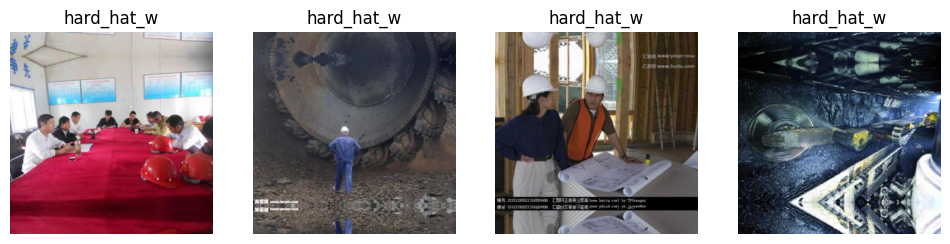

In [9]:
import random
import matplotlib.pyplot as plt

image_dir = "/content/Hard-Hat-Detection-1/train/images"

images = random.sample(os.listdir(image_dir), 4)

plt.figure(figsize=(12,5))

for i, img_name in enumerate(images):
    img_path = os.path.join(image_dir, img_name)
    img = Image.open(img_path)

    plt.subplot(1,4,i+1)
    plt.imshow(img)
    plt.title(img_name[:10])
    plt.axis('off')

plt.show()

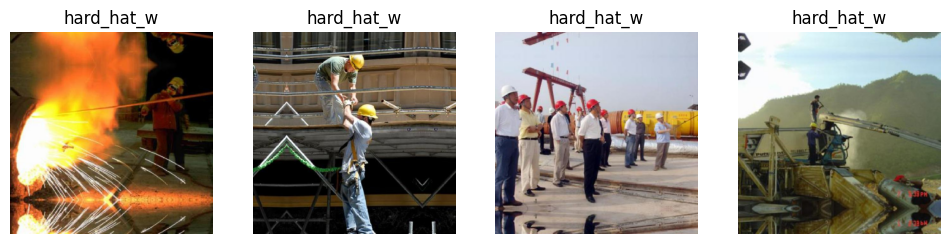

In [10]:
import random
import matplotlib.pyplot as plt

image_dir = "/content/Hard-Hat-Detection-1/valid/images"

images = random.sample(os.listdir(image_dir), 4)

plt.figure(figsize=(12,5))

for i, img_name in enumerate(images):
    img_path = os.path.join(image_dir, img_name)
    img = Image.open(img_path)

    plt.subplot(1,4,i+1)
    plt.imshow(img)
    plt.title(img_name[:10])
    plt.axis('off')

plt.show()

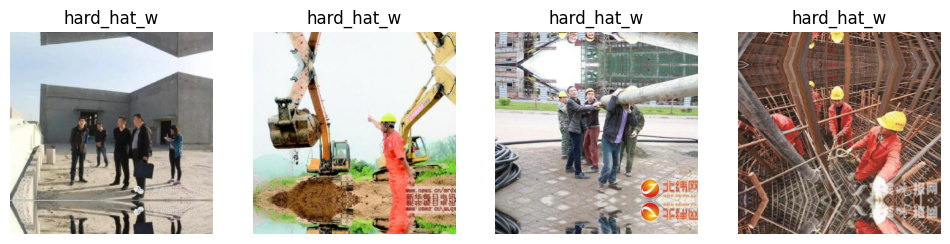

In [11]:
import random
import matplotlib.pyplot as plt

image_dir = "/content/Hard-Hat-Detection-1/test/images"

images = random.sample(os.listdir(image_dir), 4)

plt.figure(figsize=(12,5))

for i, img_name in enumerate(images):
    img_path = os.path.join(image_dir, img_name)
    img = Image.open(img_path)

    plt.subplot(1,4,i+1)
    plt.imshow(img)
    plt.title(img_name[:10])
    plt.axis('off')

plt.show()

Kode - Kode ini digunakan untuk melihat tiap images yang ada di train, test, dan valid yang digenerate secara random, hanya untuk melhat secara sekilas. Secara sekilas dapat dilihat bahwa ukuran tiap images sudah sama semua.

# Distribusi Perkelas

In [12]:
import yaml

yaml_path = os.path.join(dataset.location, 'data.yaml')

with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

print("data.yaml sebelum:", data_config)

# Update ke 2 kelas saja
data_config['nc'] = 2
data_config['names'] = ['head', 'helmet']

with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("\ndata.yaml sesudah:")
with open(yaml_path, 'r') as f:
    print(f.read())

data.yaml sebelum: {'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 3, 'names': ['head', 'helmet', 'person'], 'roboflow': {'workspace': 'neural-networks-research', 'project': 'hard-hat-detection-62dxm', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/neural-networks-research/hard-hat-detection-62dxm/dataset/1'}}

data.yaml sesudah:
names:
- head
- helmet
nc: 2
roboflow:
  license: CC BY 4.0
  project: hard-hat-detection-62dxm
  url: https://universe.roboflow.com/neural-networks-research/hard-hat-detection-62dxm/dataset/1
  version: 1
  workspace: neural-networks-research
test: ../test/images
train: ../train/images
val: ../valid/images



Di sini kami mengubah konfigurasi dataset pada file data.yaml agar hanya menggunakan dua kelas, yaitu head dan helmet.

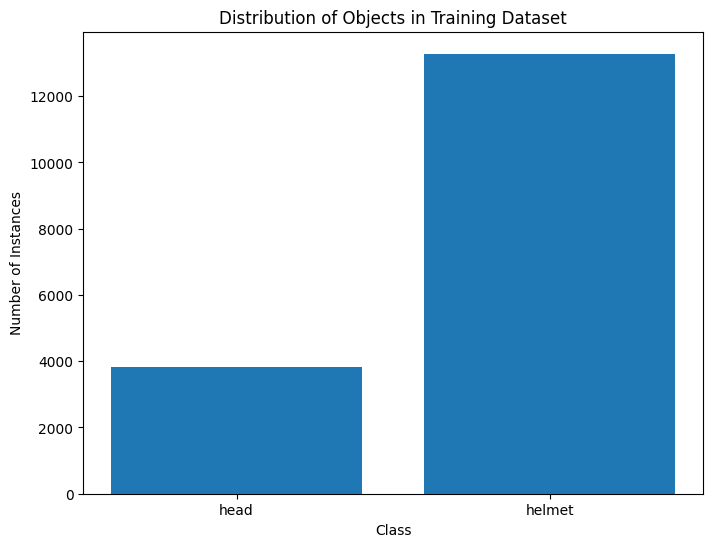

Training set distribution:
head: 3818
helmet: 13283


In [13]:
import matplotlib.pyplot as plt
import yaml
import os

data_yaml_path = '/content/Hard-Hat-Detection-1/data.yaml'
with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

classes = data_config['names']
num_classes = data_config['nc']

class_counts = {i: 0 for i in range(num_classes)}

base_data_dir = '/content/Hard-Hat-Detection-1'

# TRAIN ONLY
label_dirs = [
    os.path.join(base_data_dir, 'train', 'labels')
]

for label_dir in label_dirs:
    for label_file_name in os.listdir(label_dir):
        if label_file_name.endswith('.txt'):
            label_file_path = os.path.join(label_dir, label_file_name)
            with open(label_file_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        class_id = int(parts[0])
                        if class_id in class_counts: # Added check to ensure class_id is valid
                            class_counts[class_id] += 1

class_names = [classes[i] for i in sorted(class_counts.keys())]
counts = [class_counts[i] for i in sorted(class_counts.keys())]

plt.figure(figsize=(8,6))
plt.bar(class_names, counts)
plt.xlabel("Class")
plt.ylabel("Number of Instances")
plt.title("Distribution of Objects in Training Dataset")
plt.show()

print("Training set distribution:")
for i, name in enumerate(class_names):
    print(f"{name}: {counts[i]}")

Berdasarkan distribusi objek pada training dataset, terdapat imbalance jumlah anotasi antar kelas. Kelas helmet memiliki 13.283 dan kelas head memiliki 3.818. Imbalance ini dapat menyebabkan model lebih banyak mempelajari karakteristik objek helmet dibandingkan objek head.

# Images Size and Resolution

In [14]:
sizes = []

image_data_dirs = [
    '/content/Hard-Hat-Detection-1/train/images',
    '/content/Hard-Hat-Detection-1/valid/images',
    '/content/Hard-Hat-Detection-1/test/images'
]

for img_dir in image_data_dirs:
    if not os.path.exists(img_dir):
        print(f"Warning: Image directory not found: {img_dir}. Skipping.")
        continue
    # Take a sample, e.g., first 50 images from each directory
    for img_name in os.listdir(img_dir)[:50]: # Limiting to 50 for quick check
        img_path = os.path.join(img_dir, img_name)
        try:
            img = Image.open(img_path)
            sizes.append(img.size)
        except Exception as e:
            print(f"Error opening image {img_name} in {img_dir}: {e}")

# Check for consistency if sizes were collected
if len(sizes) > 0:
    first_size = sizes[0]
    all_sample_same_size = all(s == first_size for s in sizes)
    print(f"All sampled images have the same size ({first_size}): {all_sample_same_size}")
else:
    print("No images processed to check sizes.")

print("Sample of image sizes (first 10 collected):")
for s in sizes[:10]:
    print(s)


All sampled images have the same size ((640, 640)): True
Sample of image sizes (first 10 collected):
(640, 640)
(640, 640)
(640, 640)
(640, 640)
(640, 640)
(640, 640)
(640, 640)
(640, 640)
(640, 640)
(640, 640)


In [15]:
import pandas as pd

df_sizes = pd.DataFrame(sizes, columns=['width','height'])
print(df_sizes.describe())

       width  height
count  150.0   150.0
mean   640.0   640.0
std      0.0     0.0
min    640.0   640.0
25%    640.0   640.0
50%    640.0   640.0
75%    640.0   640.0
max    640.0   640.0


Hampir seluruh gambar sudah memiliki ukuran yang sama sehingga kami yakin bahwa proses resizing images tidak perlu dilakukan (sudah otomatis diresize oleh roboflow)

# Ratio Distribution

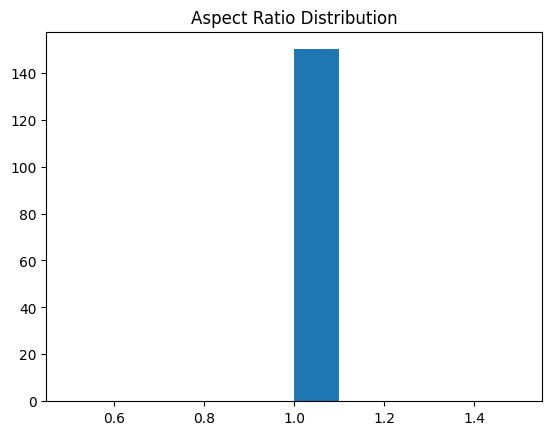

In [16]:
ratios = [w/h for w,h in sizes]

plt.hist(ratios)
plt.title("Aspect Ratio Distribution")
plt.show()

Semua images memiliki rasio yang sudah seragam, yaitu 1.

# CHECK : image corrupt, jumlah object per-image, channel rgb,ratio

In [17]:
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

def advanced_eda(dataset_path, split='train'):
    image_folder = os.path.join(dataset_path, split, 'images')
    label_folder = os.path.join(dataset_path, split, 'labels')

    data_stats = []
    corrupt_files = []


    for img_name in tqdm(os.listdir(image_folder)):
        img_path = os.path.join(image_folder, img_name)
        lab_path = os.path.join(label_folder, img_name.replace('.jpg', '.txt').replace('.png', '.txt'))

        # Cek Image Corrupt & Channel
        try:
            with Image.open(img_path) as img:
                width, height = img.size
                channels = len(img.getbands()) # RGB = 3, Grayscale = 1, RGBA = 4

                # Cek 3 channel (RGB)
                is_rgb = (channels == 3)

                # Cek Jumlah Objek
                obj_count = 0
                if os.path.exists(lab_path):
                    with open(lab_path, 'r') as f:
                        obj_count = len(f.readlines())

                data_stats.append({
                    'file': img_name,
                    'width': width,
                    'height': height,
                    'aspect_ratio': round(width/height, 2),
                    'channels': channels,
                    'obj_count': obj_count
                })
        except Exception as e:
            corrupt_files.append(img_name)

    df = pd.DataFrame(data_stats)

    print("\n--- HASIL EDA ---")
    print(f"File Corrupt: {len(corrupt_files)}")
    print(f"Rata-rata Objek per Gambar: {df['obj_count'].mean():.2f}")
    print(f"Gambar Tanpa Objek (Background): {len(df[df['obj_count'] == 0])}")
    print(f"Min Dimension: {df['width'].min()}x{df['height'].min()}")
    print(f"Max Dimension: {df['width'].max()}x{df['height'].max()}")
    print(f"Konsistensi RGB (Gambar 3-Channel): {len(df[df['channels'] == 3])} dari {len(df)} gambar")

    extreme_ar = df[(df['aspect_ratio'] > 2) | (df['aspect_ratio'] < 0.5)]
    print(f"Gambar dengan Aspect Ratio Ekstrim: {len(extreme_ar)}")

    return df

df_eda = advanced_eda(dataset.location, 'train')


100%|██████████| 3500/3500 [00:00<00:00, 7249.63it/s]


--- HASIL EDA ---
File Corrupt: 0
Rata-rata Objek per Gambar: 5.04
Gambar Tanpa Objek (Background): 0
Min Dimension: 640x640
Max Dimension: 640x640
Konsistensi RGB (Gambar 3-Channel): 3500 dari 3500 gambar
Gambar dengan Aspect Ratio Ekstrim: 0


Berdasarkan hasil EDA, dataset yang dipakai sudah cukup bagus dan rapi untuk training object detection. Tidak ada file corrupt, jadi semua gambar bisa digunakan tanpa perlu dibuang atau diperbaiki lagi. Ukuran semua gambar juga konsisten di 640×640, jadi preprocessing lebih gampang dan model bisa belajar dengan input yang sama.

Rata-rata ada sekitar 5 objek di setiap gambar, jadi model bisa belajar mendeteksi beberapa objek sekaligus dalam satu frame. Selain itu, tidak ada gambar background kosong, jadi semua data memang berisi objek yang relevan untuk training.

Semua gambar juga sudah menggunakan format RGB 3-channel dan tidak ada aspect ratio yang ekstrem. Ini bikin dataset lebih konsisten dan mengurangi kemungkinan gambar jadi distorsi saat diproses. Secara keseluruhan, dataset sudah bersih dan siap dipakai untuk training model.


# Visualisasi Data
check label dan kualitas image

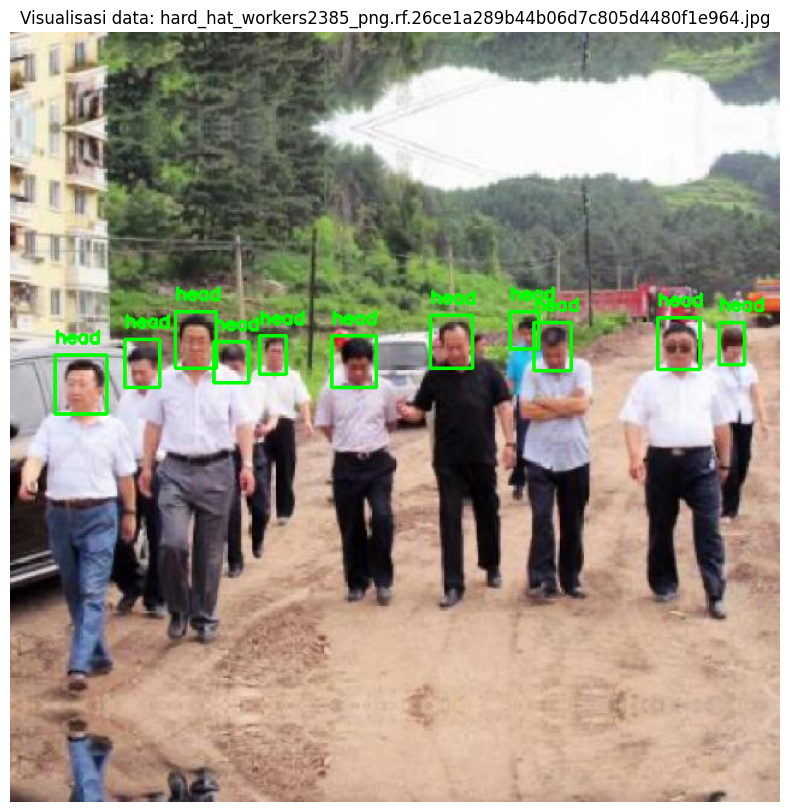

In [18]:
import cv2
import matplotlib.pyplot as plt
import random
import os

def show_sample(split='train'):
    image_dir = os.path.join(dataset.location, split, 'images')
    label_dir = os.path.join(dataset.location, split, 'labels')

    img_name = random.choice(os.listdir(image_dir))
    img_path = os.path.join(image_dir, img_name)
    label_path = os.path.join(label_dir, img_name.replace('.jpg', '.txt').replace('.png', '.txt'))

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                cls, x, y, bw, bh = map(float, line.split())

                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)
                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)

                cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(image, class_names[int(cls)], (x1, y1-10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.title(f"Visualisasi data: {img_name}")
    plt.axis('off')
    plt.show()

show_sample('train')

Pada hasil visualisasi terlihat bahwa anotasi dataset sudah sesuai, karena bounding box berhasil mengelilingi objek helmet dengan cukup tepat. Ini menunjukkan bahwa label pada dataset sudah terbaca dengan benar dan format anotasi YOLO sudah sesuai untuk proses training model object detection.


# Training Menggunakan Model YOLO

Model yang digunakan adalah YOLO11 Nano (YOLO11n) untuk tugas object detection. Model ini dipilih karena memiliki arsitektur yang ringan dan efisien, sehingga cocok untuk proses training yang lebih cepat dengan tetap memberikan performa yang baik. Framework yang digunakan adalah Ultralytics. Model ini digunakan untuk mendeteksi tiga kelas objek, yaitu head, helmet, dan person.

In [19]:
model = YOLO("yolo11n.pt")

model.train(
    data="/content/Hard-Hat-Detection-1/data.yaml",
    epochs=50,
    imgsz=640,
    patience=10
)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Hard-Hat-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x782e846405c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

*results_dict: {'metrics/precision(B)': 0.9150486028565705, 'metrics/recall(B)': 0.865570543860614, 'metrics/mAP50(B)': 0.9234830947348116, 'metrics/mAP50-95(B)': 0.5667189293077546, 'fitness': 0.5667189293077546}*


**Precision (0.9150)**

Nilai precision sebesar 91,50% menunjukkan bahwa sebagian besar prediksi objek yang dihasilkan model adalah benar. Artinya, ketika model mendeteksi objek head atau helmet, kemungkinan prediksi tersebut benar sangat tinggi sehingga jumlah false positive relatif rendah.

**Recall (0.8656)**


Nilai recall sebesar 86,56% menunjukkan bahwa model berhasil mendeteksi sebagian besar objek yang sebenarnya ada pada dataset validasi. Meskipun sudah tergolong tinggi, masih terdapat beberapa objek yang tidak terdeteksi (false negative), terutama pada kondisi yang lebih sulit seperti objek berukuran kecil, tertutup, atau kurang jelas.

**mAP@50 (0.9235)**


Nilai mAP@50 sebesar 92,35% menunjukkan bahwa model memiliki performa deteksi yang sangat baik pada threshold IoU 50%. Hasil ini menunjukkan bahwa model mampu menemukan dan mengklasifikasikan objek dengan tingkat akurasi yang tinggi.

**mAP@50-95 (0.5667)**


Nilai mAP@50-95 sebesar 56,67% menunjukkan performa model pada evaluasi yang lebih ketat karena menggunakan berbagai threshold IoU dari 50% hingga 95%. Nilai ini lebih rendah dibandingkan mAP@50, yang mengindikasikan bahwa meskipun model mampu mendeteksi objek dengan baik, ketepatan posisi dan ukuran bounding box masih dapat ditingkatkan.

**Fitness Score (0.5667)**

Nilai fitness score sebesar 56,67% merupakan metrik gabungan yang digunakan oleh Ultralytics untuk mengevaluasi performa keseluruhan model selama proses training. Nilai ini sangat dipengaruhi oleh mAP@50-95 dan digunakan untuk menentukan model terbaik (best model checkpoint) selama pelatihan. Semakin tinggi nilai fitness, semakin baik performa model secara keseluruhan.

In [20]:
df = pd.read_csv('/content/runs/detect/train/results.csv')
df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,105.221,1.64446,1.86419,1.23477,0.80128,0.70917,0.79369,0.40925,1.61357,1.21193,1.25211,0.000553,0.000553,0.000553
1,2,180.942,1.58385,1.26457,1.20761,0.77140,0.67685,0.75493,0.39169,1.66375,1.22351,1.28599,0.001087,0.001087,0.001087
2,3,256.965,1.57667,1.15068,1.22021,0.74952,0.68671,0.76282,0.41069,1.56777,1.09844,1.25803,0.001598,0.001598,0.001598
3,4,332.424,1.56544,1.07508,1.20268,0.83510,0.75246,0.82183,0.45404,1.50917,0.96571,1.21779,0.001568,0.001568,0.001568
4,5,407.501,1.53315,1.02563,1.20128,0.84009,0.77084,0.84461,0.47199,1.48213,0.93702,1.21320,0.001535,0.001535,0.001535


## Best Epoch Berdasarkan mAP50-95, mAP50, validation box

In [21]:
best_epoch = df['metrics/mAP50-95(B)'].idxmax()
best_epoch + 1

47

In [22]:
best_epoch_map50 = df['metrics/mAP50(B)'].idxmax()
best_epoch_map50

45

In [23]:
best_epoch_val = df['val/box_loss'].idxmin()
best_epoch_val

49

Berdasarkan hasil evaluasi, model terbaik diperoleh pada epoch ke-47, ditentukan berdasarkan nilai mAP50-95 tertinggi serta validation box loss terendah, yang menunjukkan performa generalisasi model terbaik pada epoch tersebut. metrik mAP50-95 dipilih sebagai acuan utama karena memberikan evaluasi yang lebih ketat dan lebih representatif terhadap performa model object detection secara keseluruhan.

# Evaluations

### train

In [24]:
os.listdir('/content/runs/detect/train')

['val_batch0_labels.jpg',
 'confusion_matrix.png',
 'train_batch8521.jpg',
 'labels.jpg',
 'val_batch1_labels.jpg',
 'BoxR_curve.png',
 'args.yaml',
 'BoxF1_curve.png',
 'BoxP_curve.png',
 'val_batch2_pred.jpg',
 'train_batch1.jpg',
 'train_batch8520.jpg',
 'confusion_matrix_normalized.png',
 'BoxPR_curve.png',
 'val_batch1_pred.jpg',
 'val_batch2_labels.jpg',
 'train_batch8522.jpg',
 'results.png',
 'weights',
 'train_batch0.jpg',
 'results.csv',
 'train_batch2.jpg',
 'val_batch0_pred.jpg']

Folder hasil evaluasi dan training berisi beberapa file visualisasi dan output penting dari proses training YOLO. File seperti `BoxPR_curve.png`, `BoxF1_curve.png`, `BoxP_curve.png`, dan `BoxR_curve.png` digunakan untuk melihat performa model dari sisi precision, recall, dan F1-score. File `confusion_matrix.png` menunjukkan hasil klasifikasi model untuk tiap kelas. Gambar seperti `val_batch0_pred.jpg`, `val_batch1_pred.jpg`, dan `val_batch2_pred.jpg` menampilkan hasil prediksi model pada data validasi, sedangkan file dengan nama `labels` menunjukkan ground truth asli dataset. Selain itu, terdapat `results.csv` dan `results.png` yang berisi ringkasan hasil training setiap epoch, serta folder `weights` yang menyimpan model hasil training terbaik dan terakhir.


### test

In [25]:
import matplotlib.image as mpimg

model = YOLO('/content/runs/detect/train/weights/best.pt')

# evaluasi test set
model.val(
    data='/content/Hard-Hat-Detection-1/data.yaml',
    split='test',
    project='/content/evaluations',
    name='test_eval_v1',
    exist_ok=True
)

os.listdir('/content/evaluations/test_eval_v1')

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1438.3±586.3 MB/s, size: 50.1 KB)
val: Scanning /content/Hard-Hat-Detection-1/test/labels... 500 images, 0 backgrounds, 13 corrupt: 100% ━━━━━━━━━━━━ 500/500 2.0Kit/s 0.2s
val: /content/Hard-Hat-Detection-1/test/images/hard_hat_workers1022_png.rf.9160c68da3e2854d01493902e1669fa0.jpg: ignoring corrupt image/label: Label class 2 exceeds dataset class count 2. Possible class labels are 0-1
val: /content/Hard-Hat-Detection-1/test/images/hard_hat_workers1174_png.rf.28965107ef1c89e8bba51679a32c20eb.jpg: ignoring corrupt image/label: Label class 2 exceeds dataset class count 2. Possible class labels are 0-1
val: /content/Hard-Hat-Detection-1/test/images/hard_hat_workers1351_png.rf.36b326644ca39be1426c3fe2d36d0d4d.jpg: ignoring corrupt image/label: Label class 2 exceeds dataset cla

['val_batch0_labels.jpg',
 'confusion_matrix.png',
 'val_batch1_labels.jpg',
 'BoxR_curve.png',
 'BoxF1_curve.png',
 'BoxP_curve.png',
 'val_batch2_pred.jpg',
 'confusion_matrix_normalized.png',
 'BoxPR_curve.png',
 'val_batch1_pred.jpg',
 'val_batch2_labels.jpg',
 'val_batch0_pred.jpg']

Hasil evaluasi menunjukkan bahwa model memiliki performa yang baik dalam mendeteksi objek head dan helmet. Secara keseluruhan, model mencapai nilai Precision sebesar 90,7%, Recall sebesar 86,7%, mAP@50 sebesar 92,3%, dan mAP@50-95 sebesar 56,6%. Kelas helmet menunjukkan performa yang sedikit lebih baik dibandingkan kelas head, dengan mAP@50 sebesar 93,7% dan mAP@50-95 sebesar 58,7%, sedangkan kelas head memperoleh mAP@50 sebesar 91,0% dan mAP@50-95 sebesar 54,6%. Hasil ini menunjukkan bahwa model mampu mengenali kedua objek dengan tingkat akurasi yang tinggi, terutama pada kelas helmet. Selain itu, kecepatan inferensi yang mencapai sekitar 2,6 gambar per detik menunjukkan bahwa model memiliki potensi untuk diterapkan pada sistem deteksi secara real-time atau mendekati real-time.

### Results Evaluation

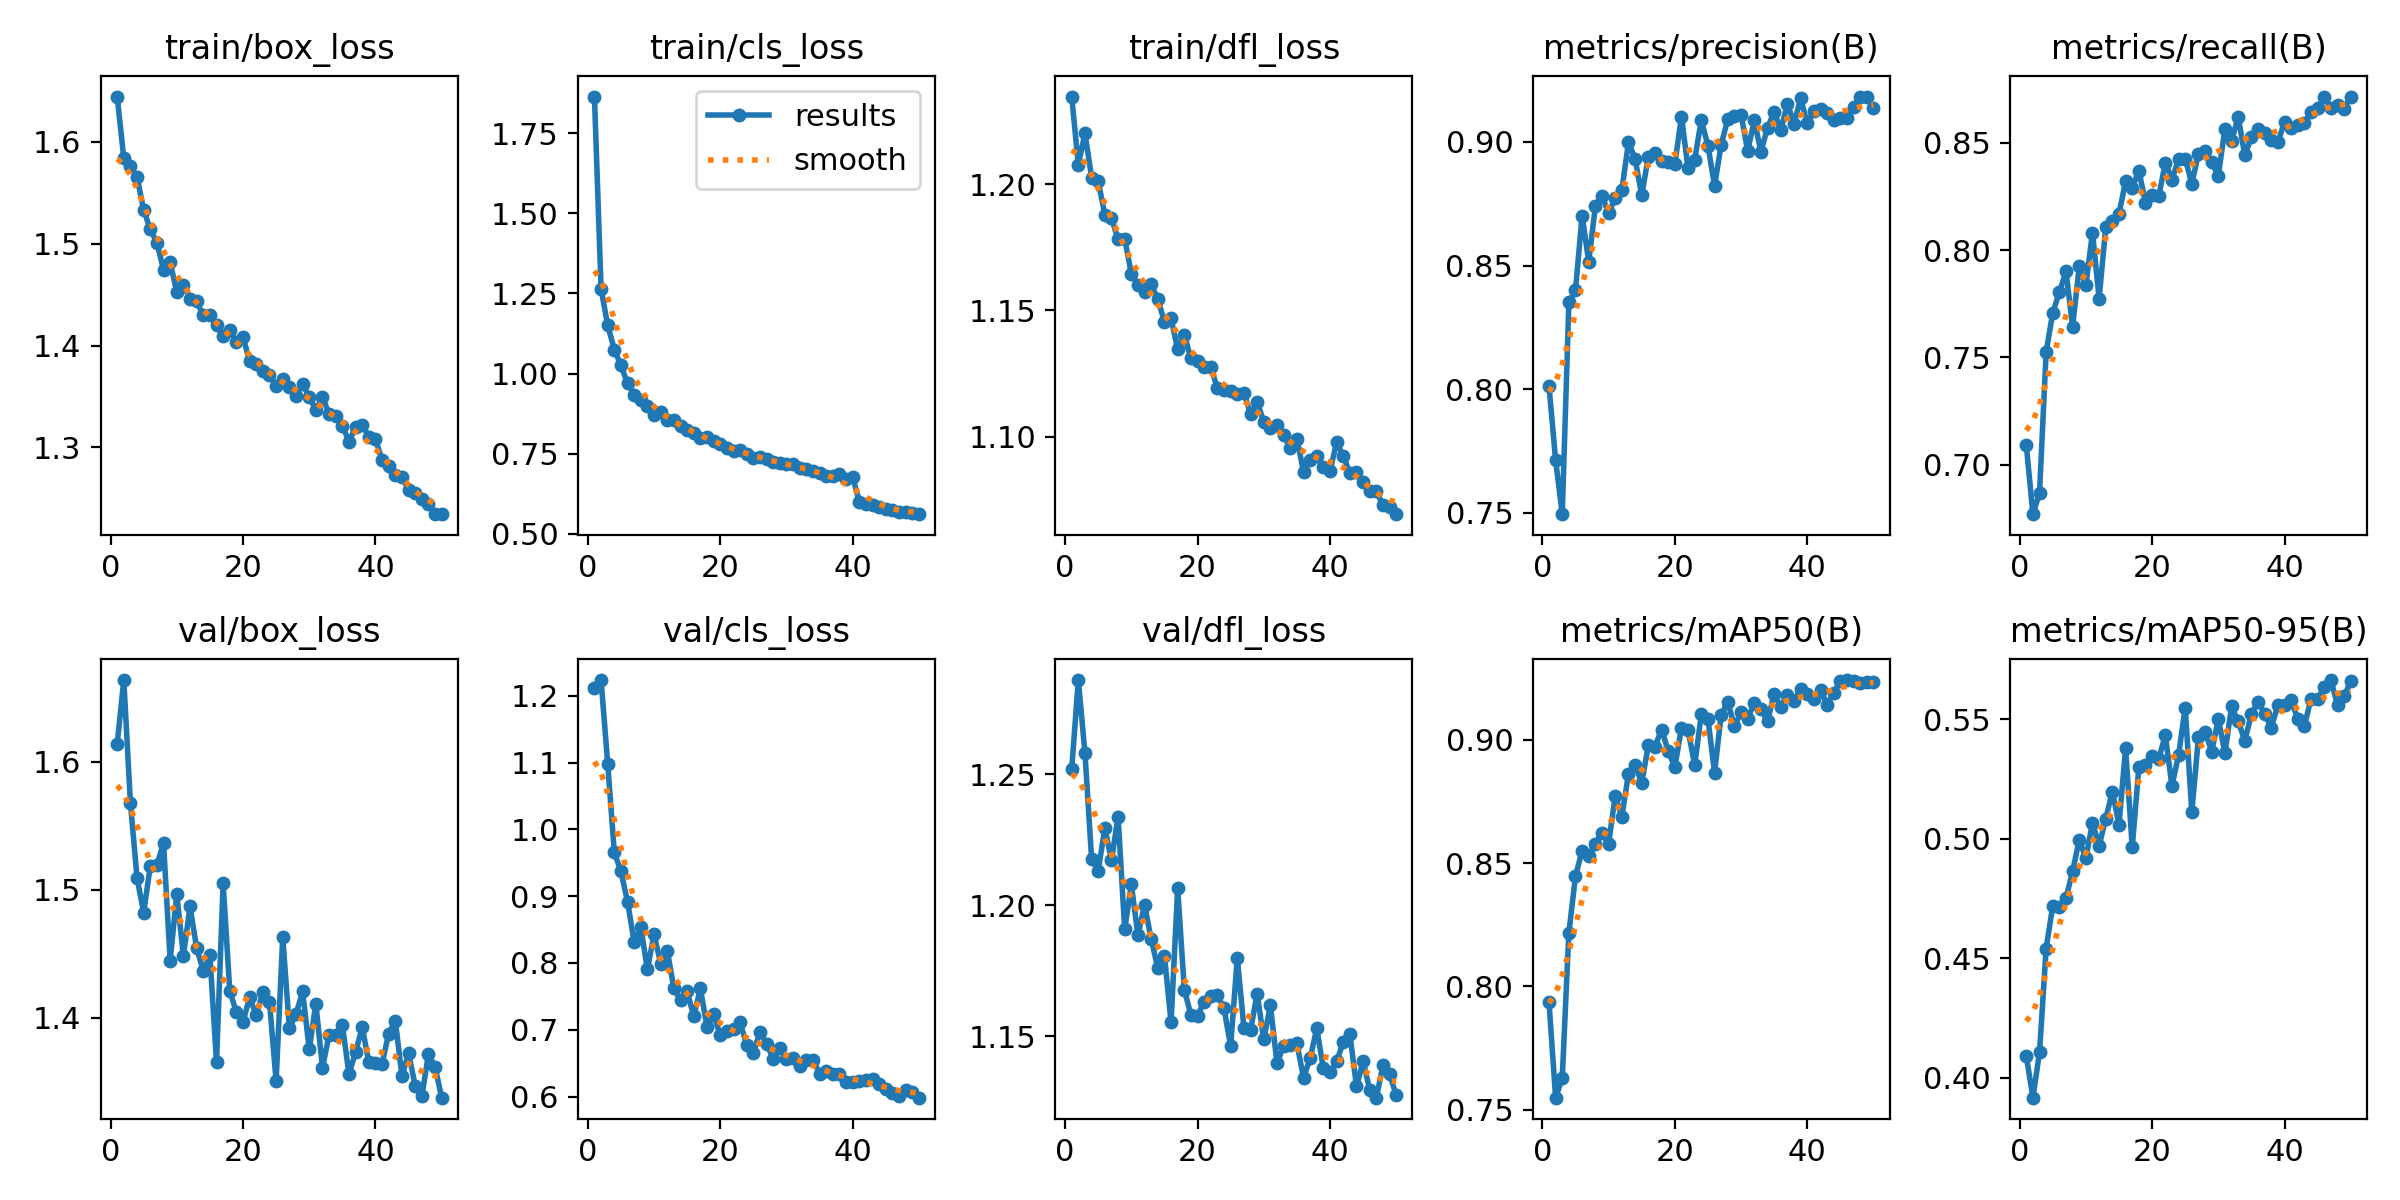

In [30]:
from IPython.display import Image

Image('/content/runs/detect/train/results.png')

**Train Box Loss**

Train box loss menurun dari sekitar 1,62 menjadi 1,23, menunjukkan bahwa model semakin baik dalam menentukan lokasi objek pada data training. Penurunan yang konsisten menandakan proses pembelajaran berjalan dengan baik.


**Train Classification Loss**


Train classification loss turun dari sekitar 1,85 menjadi 0,55, yang menunjukkan bahwa model semakin akurat dalam membedakan dan mengklasifikasikan objek head dan helmet selama proses training.

**Train DFL Loss**


Train DFL loss menurun dari sekitar 1,21 menjadi 1,07, menandakan adanya peningkatan kemampuan model dalam menentukan posisi dan ukuran bounding box secara lebih presisi.

**Validation Box Loss**


Validation box loss menurun dari sekitar 1,67 menjadi 1,34. Meskipun terdapat beberapa fluktuasi pada awal training, tren yang terus menurun menunjukkan bahwa model mampu melakukan generalisasi dengan baik pada data validasi.

**Validation Classification Loss**

Validation classification loss turun dari sekitar 1,22 menjadi 0,60, yang menunjukkan bahwa kemampuan model dalam mengenali kelas objek pada data yang belum pernah dilihat sebelumnya semakin meningkat.

**Validation DFL Loss**


Validation DFL loss menurun dari sekitar 1,29 menjadi 1,13, yang menunjukkan bahwa ketepatan model dalam menempatkan bounding box pada data validasi semakin baik seiring bertambahnya epoch.

Head

Untuk kelas head, model menghasilkan performa yang baik dengan nilai AP sebesar 0,882. Kurva tetap berada pada area atas grafik untuk sebagian besar rentang recall, yang menunjukkan bahwa model mampu mempertahankan precision yang tinggi sambil tetap mendeteksi sebagian besar objek head. Hal ini menunjukkan bahwa deteksi pada kelas head sudah cukup akurat dan konsisten.

Helmet

Kelas helmet memiliki performa yang lebih baik dengan nilai AP sebesar 0,936. Kurvanya berada sangat dekat dengan sudut kanan atas grafik, yang menunjukkan bahwa model mampu mendeteksi objek helmet dengan tingkat akurasi yang sangat tinggi. Hasil ini mengindikasikan bahwa karakteristik visual helmet lebih mudah dipelajari oleh model dibandingkan kelas head.

Keseluruhan Model

Secara keseluruhan, model memperoleh mAP@0.5 sebesar 0,909. Nilai ini menunjukkan bahwa model memiliki performa deteksi yang sangat baik dalam mengenali objek head dan helmet. Kurva Precision-Recall yang berada pada area atas grafik juga menunjukkan bahwa model mampu menjaga keseimbangan yang baik antara precision dan recall.

Kesimpulan

Model menunjukkan performa yang sangat baik untuk kedua kelas yang diuji. Kelas helmet memiliki hasil deteksi yang sedikit lebih unggul dibandingkan head, namun keduanya tetap mencapai tingkat akurasi yang tinggi. Dengan nilai mAP@0.5 sebesar 90,9%, model dapat dikatakan telah berhasil mempelajari karakteristik objek head dan helmet dengan baik serta mampu melakukan deteksi secara akurat pada data yang diuji.

### Confusion Matrix Train

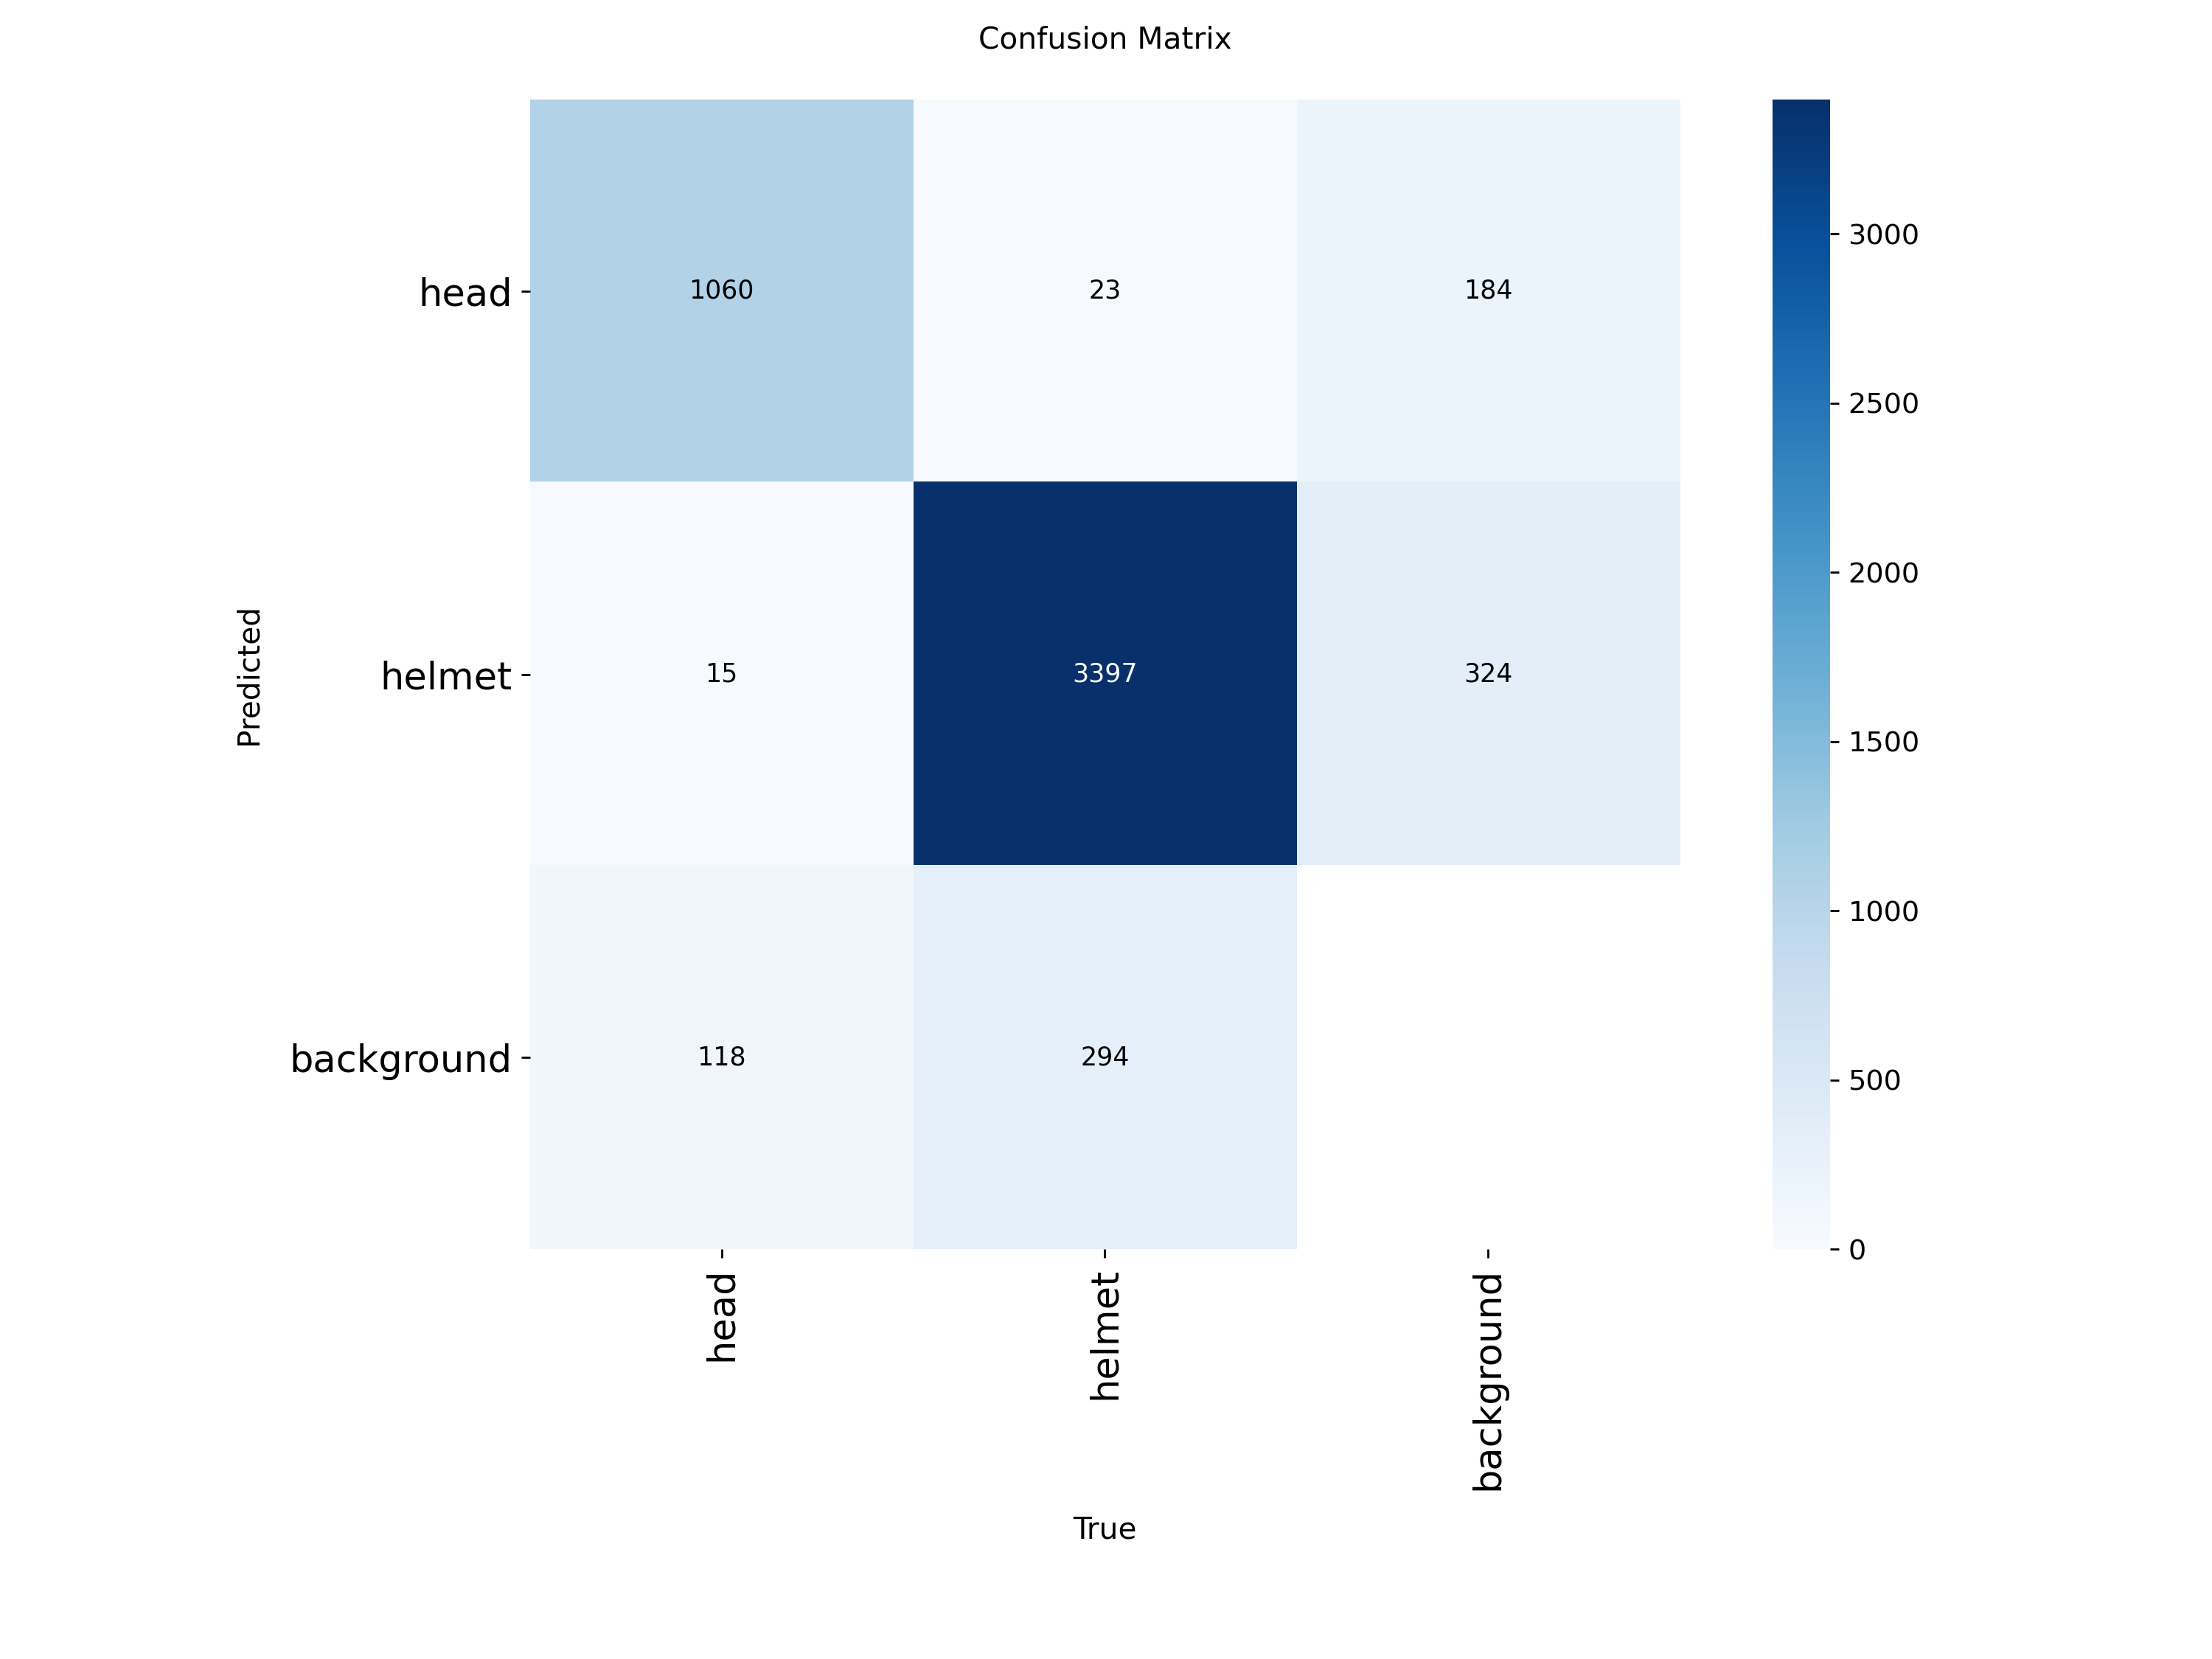

In [31]:
Image('/content/runs/detect/train/confusion_matrix.png')

Interpretasi Confusion Matrix:

Confusion matrix ini menunjukkan seberapa sering model memprediksi setiap kelas dengan benar maupun salah.

* Head

Model berhasil mendeteksi 1060 objek head dengan benar. Selain itu, terdapat 23 objek helmet yang salah diprediksi sebagai head. Model juga menghasilkan 184 prediksi head pada area yang sebenarnya merupakan background (false positive). Hal ini menunjukkan bahwa model sudah cukup baik dalam mengenali objek head, meskipun masih terdapat beberapa kesalahan deteksi.

* Helmet

Kelas helmet memiliki performa yang sangat baik. Model berhasil mendeteksi 3397 objek helmet dengan benar, sementara hanya 15 objek head yang salah diprediksi sebagai helmet. Namun, masih terdapat 324 prediksi helmet pada area background, yang menunjukkan bahwa model terkadang mendeteksi objek yang sebenarnya tidak ada.

* Background (missed detection)
Baris background menunjukkan objek yang seharusnya terdeteksi tetapi terlewat oleh model (false negative). Terdapat 118 objek head dan 294 objek helmet yang tidak berhasil dideteksi sehingga diklasifikasikan sebagai background.
    

* Kesimpulan
Secara keseluruhan, model menunjukkan performa yang sangat baik dalam mendeteksi kedua kelas. Kelas helmet memiliki hasil deteksi yang sedikit lebih baik dibandingkan head, yang terlihat dari jumlah prediksi benar yang lebih tinggi dan kesalahan klasifikasi yang lebih rendah. Selain itu, jumlah kesalahan antara kelas head dan helmet relatif kecil, sehingga model mampu membedakan kedua objek dengan baik. Meskipun masih terdapat beberapa false positive dan false negative, hasil confusion matrix menunjukkan bahwa model memiliki kemampuan deteksi yang kuat dan konsisten terhadap objek head dan helmet.



### Confusion Matrix Test

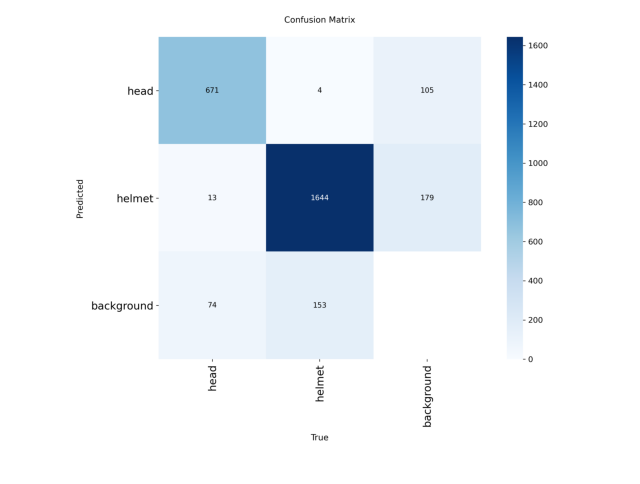

In [32]:
img = mpimg.imread('/content/evaluations/test_eval_v1/confusion_matrix.png')

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis('off')
plt.show()

**Interpretasi Confusion Matrix (Test)**

Hasil confusion matrix pada data test menunjukkan bahwa model memiliki kemampuan yang baik dalam membedakan objek head dan helmet. Kelas helmet memberikan hasil terbaik dengan 1644 prediksi benar, sedangkan kelas head berhasil dideteksi dengan benar sebanyak 671 objek. Jumlah kesalahan klasifikasi antar kedua kelas juga relatif rendah, di mana hanya terdapat 4 objek helmet yang diprediksi sebagai head dan 13 objek head yang diprediksi sebagai helmet. Hal ini menunjukkan bahwa model mampu membedakan kedua kelas dengan cukup akurat.

Selain itu, masih terdapat beberapa objek yang tidak berhasil dideteksi oleh model. Sebanyak 74 objek head dan 153 objek helmet terklasifikasi sebagai background, yang menunjukkan adanya kasus missed detection. Di sisi lain, terdapat 105 prediksi head dan 179 prediksi helmet pada area yang sebenarnya merupakan background, yang menunjukkan adanya beberapa false positive.

**Perbandingan Train dan Test**

Jika dibandingkan dengan confusion matrix pada data train, hasil pada data test menunjukkan pola yang serupa. Kelas helmet tetap menjadi kelas dengan performa terbaik, diikuti oleh kelas head. Pada kedua dataset, jumlah prediksi benar untuk helmet lebih tinggi dibandingkan head, serta jumlah kesalahan klasifikasi antar kedua kelas relatif rendah.

Performa pada data test memang sedikit lebih rendah dibandingkan data train, yang merupakan kondisi yang wajar karena model diuji menggunakan gambar yang belum pernah dilihat sebelumnya. Meskipun demikian, model tetap mampu mendeteksi objek head dan helmet dengan baik serta mempertahankan pola prediksi yang konsisten.

Secara keseluruhan, kemiripan hasil antara confusion matrix train dan test menunjukkan bahwa model memiliki kemampuan generalisasi yang baik. Hal ini menandakan bahwa model tidak hanya menghafal data training, tetapi juga mampu mengenali objek head dan helmet pada data baru dengan tingkat akurasi yang tetap tinggi.

# Training and Validation Result

## Training Dataset Distribution (Ini tadi udah diatas)

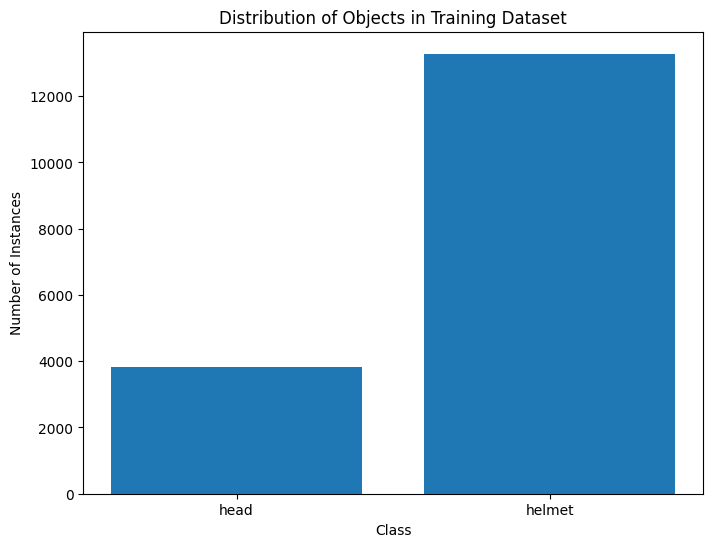

In [34]:
data_yaml_path = '/content/Hard-Hat-Detection-1/data.yaml'
with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

classes = data_config['names']
num_classes = data_config['nc']

class_counts = {i: 0 for i in range(num_classes)}

label_dir = '/content/Hard-Hat-Detection-1/train/labels'

for label_file_name in os.listdir(label_dir):
    if label_file_name.endswith('.txt'):
        with open(os.path.join(label_dir, label_file_name), 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    class_id = int(parts[0])
                    if class_id < num_classes: # Added check to ensure class_id is valid
                        class_counts[class_id] += 1

class_names = [classes[i] for i in sorted(class_counts.keys())]
counts = [class_counts[i] for i in sorted(class_counts.keys())]

plt.figure(figsize=(8,6))
plt.bar(class_names, counts)
plt.title("Distribution of Objects in Training Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Instances")
plt.show()

Grafik ini menunjukkan bahwa jumlah objek helmet pada data training jauh lebih banyak dibandingkan head, yaitu sekitar 13.283 objek berbanding 3.818 objek. Ketidakseimbangan data ini membuat model lebih banyak belajar dari kelas helmet, sehingga performa deteksi helmet sedikit lebih baik dibandingkan head pada hasil evaluasi.

## Training and Validation Loss Results

<Axes: >

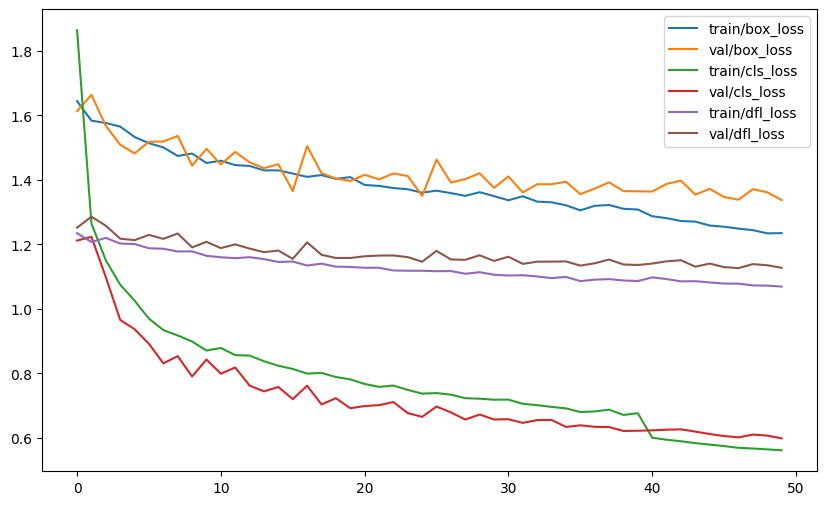

In [35]:
df = pd.read_csv('/content/runs/detect/train/results.csv')

df[['train/box_loss','val/box_loss',
    'train/cls_loss','val/cls_loss',
    'train/dfl_loss','val/dfl_loss']].plot(figsize=(10,6))

Grafik menunjukkan bahwa nilai training loss dan validation loss terus menurun hingga akhir training. Hal ini menandakan bahwa model semakin baik dalam mendeteksi dan mengklasifikasikan objek. Selain itu, pola validation loss yang mengikuti training loss menunjukkan bahwa model tidak mengalami overfitting yang signifikan dan mampu melakukan generalisasi dengan baik pada data baru.


## Validation Performaance Metrics

In [36]:
val_metrics = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'mAP@50', 'mAP@50-95'],
    'Best Value': [
        df['metrics/precision(B)'].max(),
        df['metrics/recall(B)'].max(),
        df['metrics/mAP50(B)'].max(),
        df['metrics/mAP50-95(B)'].max()
    ]
})

val_metrics

,Metric,Best Value
0,Precision,0.91831
1,Recall,0.87160
2,mAP@50,0.92420
3,mAP@50-95,0.56633


Hasil evaluasi menunjukkan bahwa model memiliki performa yang sangat baik dengan nilai precision sebesar 91,83%, yang berarti sebagian besar prediksi yang dihasilkan model sudah tepat. Selain itu, nilai recall sebesar 87,16% menunjukkan bahwa model mampu mendeteksi sebagian besar objek yang terdapat pada dataset, meskipun masih ada sejumlah kecil objek yang belum berhasil terdeteksi. Nilai mAP@50 sebesar 92,42% menunjukkan kemampuan deteksi objek yang sangat baik, sedangkan mAP@50-95 sebesar 56,63% mengindikasikan bahwa ketepatan posisi bounding box masih dapat ditingkatkan pada ambang IoU yang lebih ketat. Secara keseluruhan, model menunjukkan performa yang kuat dalam mendetksi objek head dan helmet.

## Validation Precision - Recall Curve

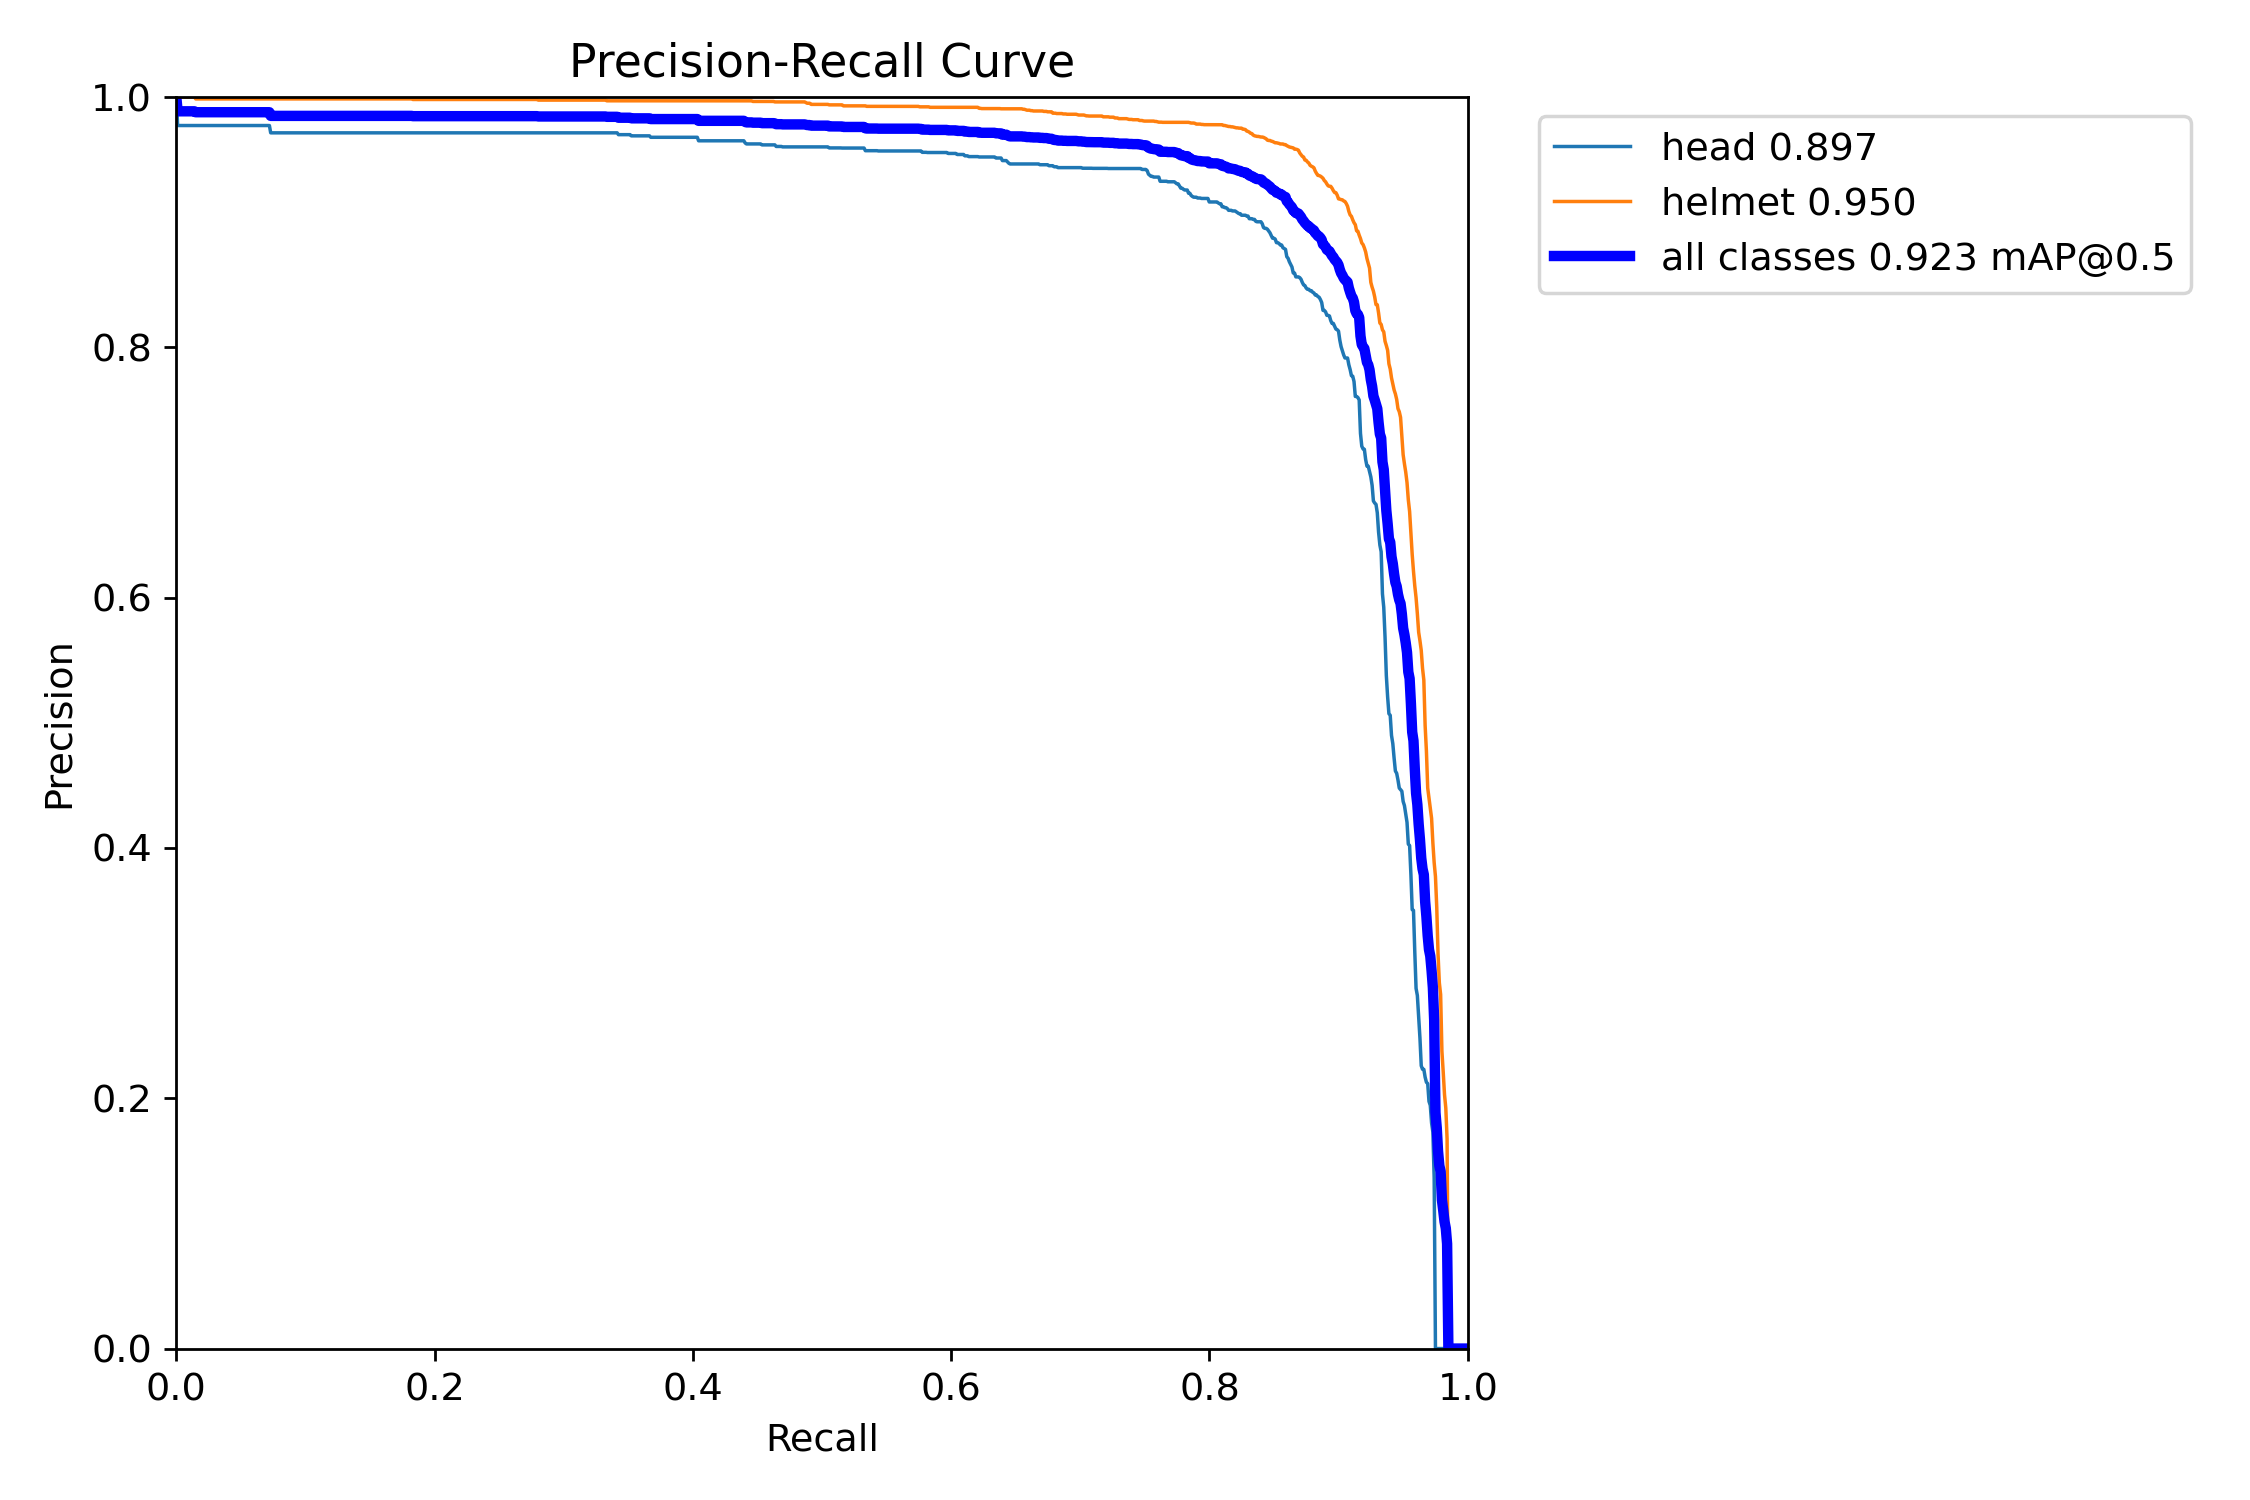

In [37]:
display(Image('/content/runs/detect/train/BoxPR_curve.png'))

Grafik Precision-Recall menunjukkan bahwa model memiliki performa yang sangat baik dalam mendeteksi kedua kelas, yaitu head dan helmet. Kelas helmet menunjukkan hasil yang sedikit lebih baik dibandingkan head, yang terlihat dari nilai Average Precision (AP) yang lebih tinggi. Kurva kedua kelas berada pada area atas grafik, yang menunjukkan bahwa model mampu mempertahankan precision yang tinggi sekaligus mendeteksi sebagian besar objek yang ada. Secara keseluruhan, hasil ini menunjukkan bahwa model telah mampu mengenali objek head dan helmet dengan tingkat akurasi yang tinggi.

## Validation F1 Curve

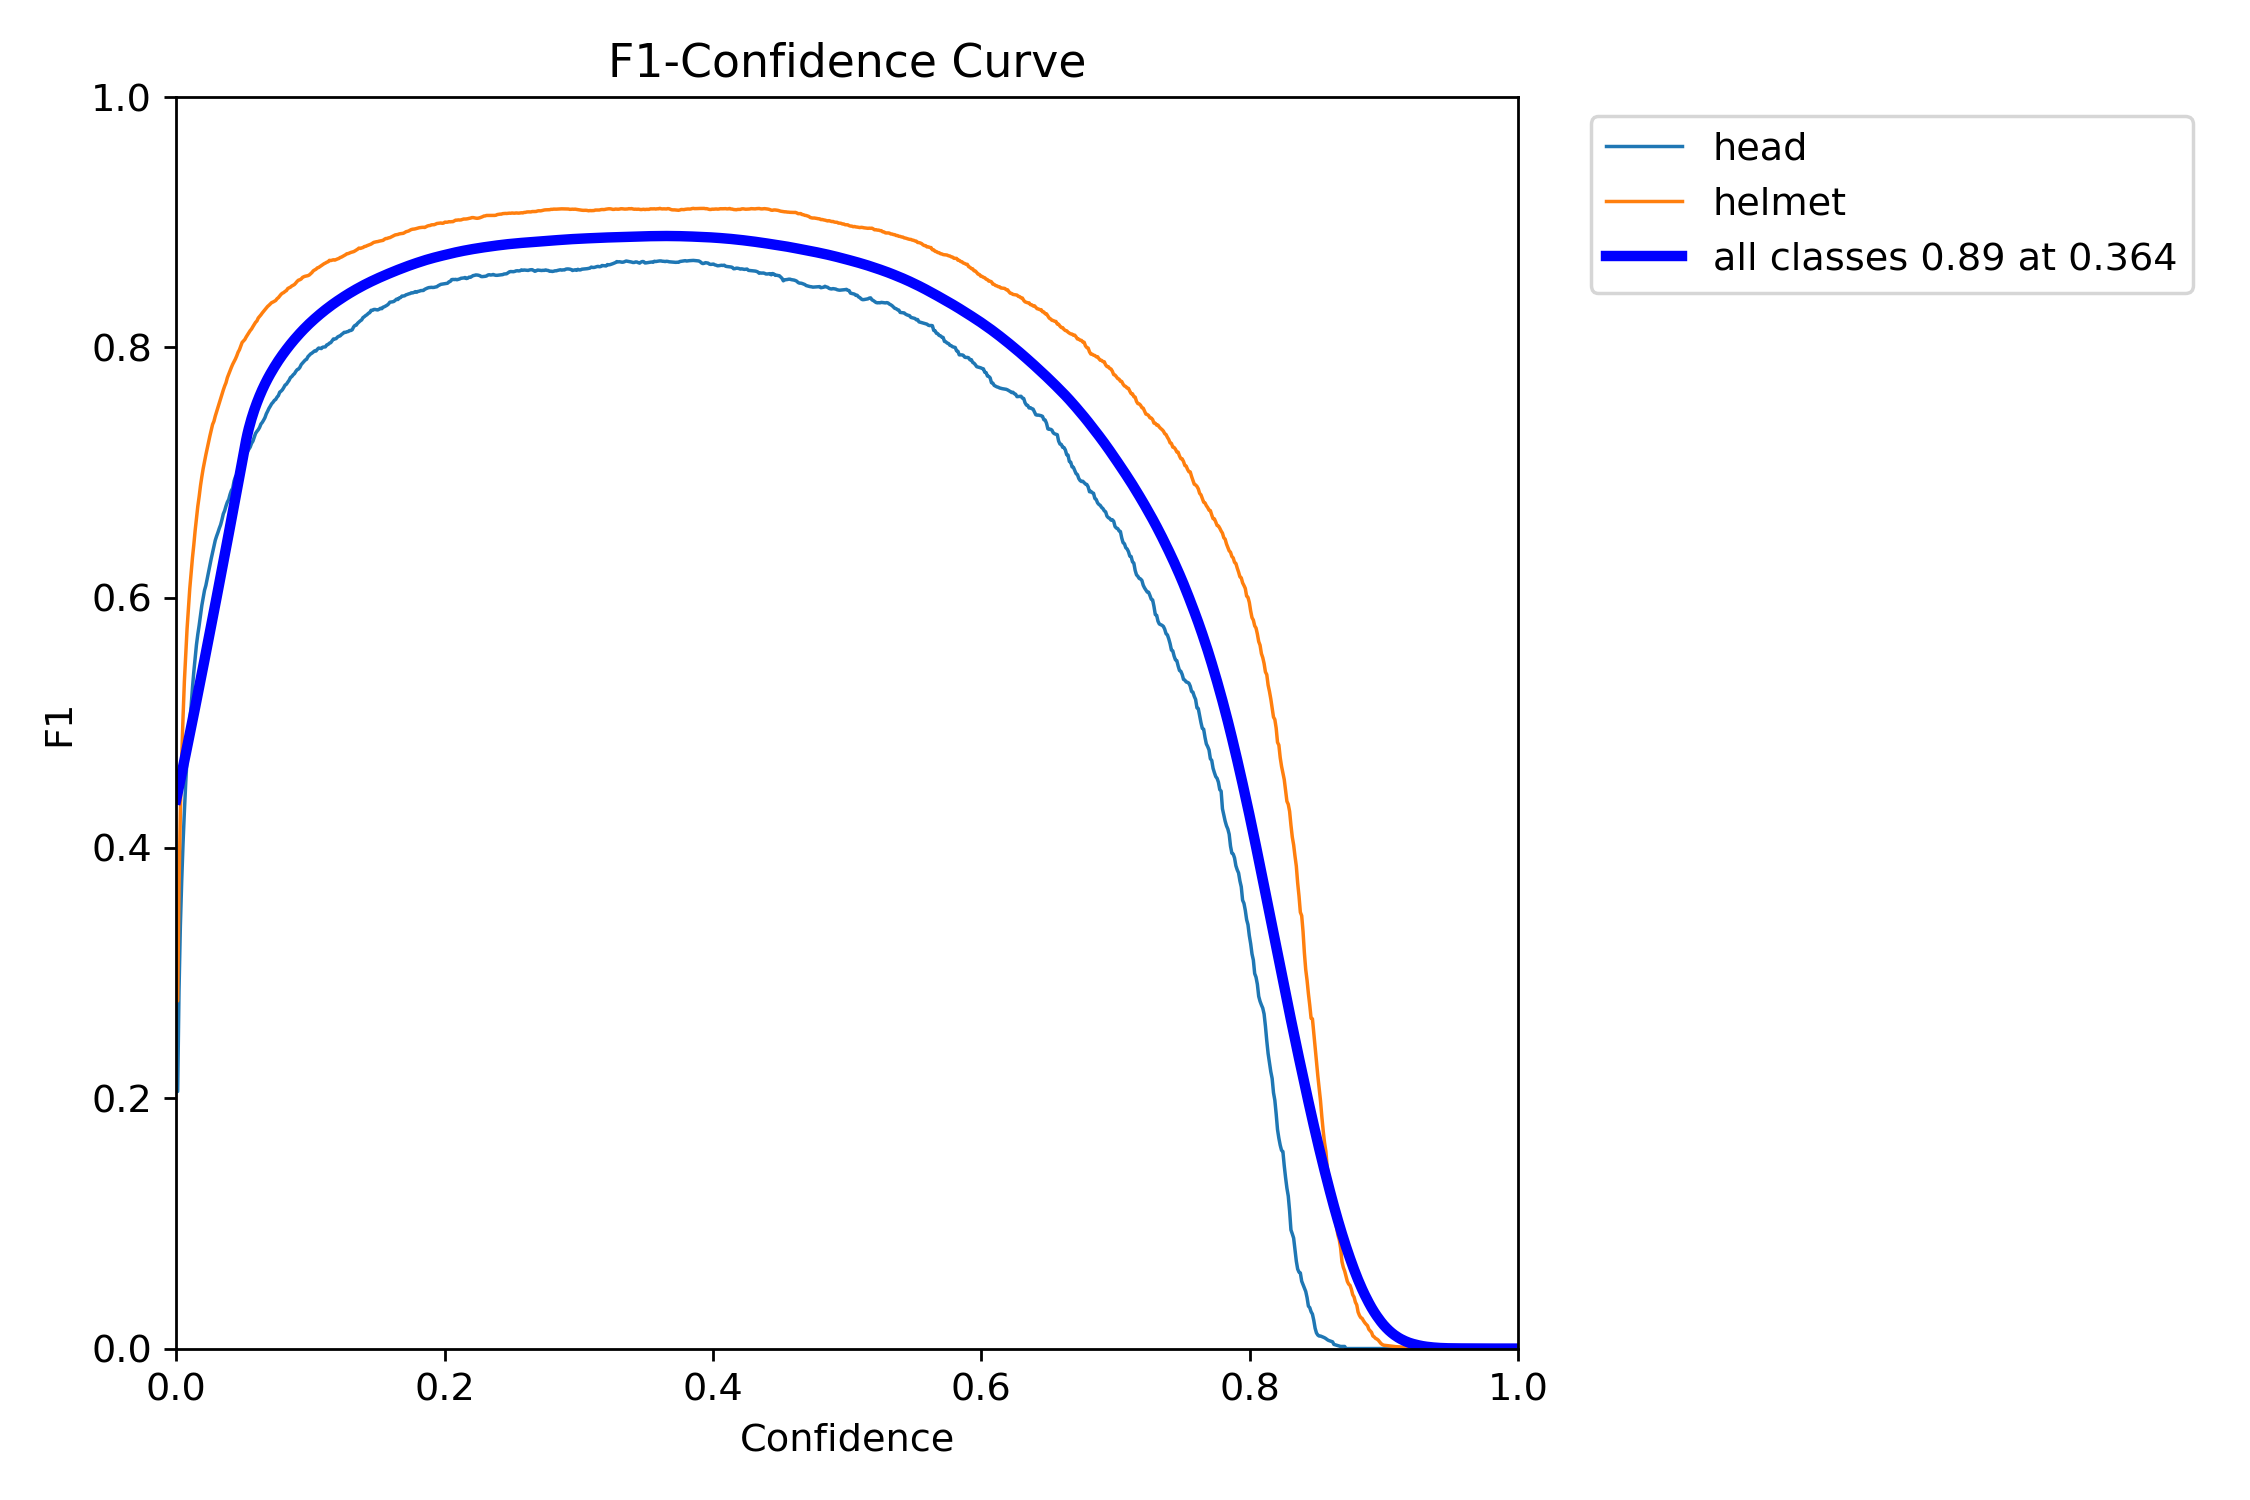

In [38]:
display(Image('/content/runs/detect/train/BoxF1_curve.png'))

Grafik F1-Confidence menunjukkan bahwa kelas helmet memiliki performa yang sedikit lebih baik dibandingkan kelas head, yang terlihat dari nilai F1 yang lebih tinggi pada hampir seluruh rentang confidence threshold. Kedua kurva mencapai nilai F1 yang tinggi dan relatif stabil pada confidence menengah, yang menunjukkan bahwa model mampu menjaga keseimbangan yang baik antara precision dan recall. Secara keseluruhan, model mencapai nilai F1 terbaik sebesar 0,89 pada confidence threshold sekitar 0,364. Hal ini menunjukkan bahwa threshold tersebut merupakan nilai yang paling optimal untuk menghasilkan performa deteksi terbaik pada model.

# Evaluation Results

## Test Set Overall Performance Metrics

In [39]:
model = YOLO('/content/runs/detect/train/weights/best.pt')

metrics = model.val(
    data='/content/Hard-Hat-Detection-1/data.yaml',
    split='test',
    project='/content/evaluations',
    name='test_eval_v1',
    exist_ok=True
)

overall_metrics = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'mAP@50', 'mAP@50-95'],
    'Value': [
        metrics.box.mp,
        metrics.box.mr,
        metrics.box.map50,
        metrics.box.map
    ]
})

overall_metrics

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1503.2±346.1 MB/s, size: 49.2 KB)
val: Scanning /content/Hard-Hat-Detection-1/test/labels.cache... 500 images, 0 backgrounds, 13 corrupt: 100% ━━━━━━━━━━━━ 500/500 149.8Mit/s 0.0s
val: /content/Hard-Hat-Detection-1/test/images/hard_hat_workers1022_png.rf.9160c68da3e2854d01493902e1669fa0.jpg: ignoring corrupt image/label: Label class 2 exceeds dataset class count 2. Possible class labels are 0-1
val: /content/Hard-Hat-Detection-1/test/images/hard_hat_workers1174_png.rf.28965107ef1c89e8bba51679a32c20eb.jpg: ignoring corrupt image/label: Label class 2 exceeds dataset class count 2. Possible class labels are 0-1
val: /content/Hard-Hat-Detection-1/test/images/hard_hat_workers1351_png.rf.36b326644ca39be1426c3fe2d36d0d4d.jpg: ignoring corrupt image/label: Label class 2 exceeds dat

,Metric,Value
0,Precision,0.907462
1,Recall,0.866953
2,mAP@50,0.923340
3,mAP@50-95,0.566494


Berdasarkan hasil evaluasi, model YOLO11n menunjukkan performa yang baik dalam mendeteksi objek head dan helmet. Model memperoleh precision sebesar 90,75%, yang berarti sebagian besar prediksi yang dihasilkan model sudah benar sehingga jumlah false positive relatif rendah.

Nilai recall sebesar 86,70% menunjukkan bahwa model mampu mendeteksi sebagian besar objek yang ada pada dataset, meskipun masih terdapat beberapa objek yang belum berhasil terdeteksi. Dari sisi akurasi deteksi, model mencapai mAP@50 sebesar 92,33%, yang menunjukkan kemampuan deteksi objek yang sangat baik. Sementara itu, nilai mAP@50-95 sebesar 56,65% mengindikasikan bahwa model masih dapat ditingkatkan dalam menentukan posisi dan ukuran bounding box secara lebih presisi pada berbagai tingkat IoU yang lebih ketat.

Selain itu, kelas helmet cenderung memiliki performa yang sedikit lebih baik dibandingkan kelas head. Hal ini kemungkinan dipengaruhi oleh jumlah data helmet yang lebih banyak pada dataset, sehingga model memiliki lebih banyak contoh untuk dipelajari selama proses training.

Secara keseluruhan, hasil evaluasi menunjukkan bahwa YOLO11n mampu mendeteksi objek head dan helmet dengan baik serta memiliki potensi untuk digunakan pada aplikasi pemantauan keselamatan kerja secara otomatis.

## Per-Class Test Performance Metrics

In [40]:
per_class_metrics = pd.DataFrame({
    'Class': list(model.names.values()),
    'Precision': metrics.box.p,
    'Recall': metrics.box.r,
    'mAP@50': metrics.box.ap50,
    'mAP@50-95': metrics.box.ap
})

per_class_metrics

,Class,Precision,Recall,mAP@50,mAP@50-95
0,head,0.899351,0.848761,0.909709,0.546128
1,helmet,0.915573,0.885145,0.936971,0.586860


Berdasarkan hasil evaluasi per kelas, model menunjukkan performa yang sangat baik pada kedua kelas. Kelas helmet memiliki hasil terbaik dengan Precision 91,56%, Recall 88,51%, dan mAP@50 93,70%. Sementara itu, kelas head juga memiliki performa yang baik dengan Precision 89,94%, Recall 84,88%, dan mAP@50 90,97%. Secara keseluruhan, model mampu mendeteksi objek head dan helmet dengan akurasi yang tinggi, dengan performa helmet sedikit lebih baik dibandingkan head.

## Test Confusion Matrix

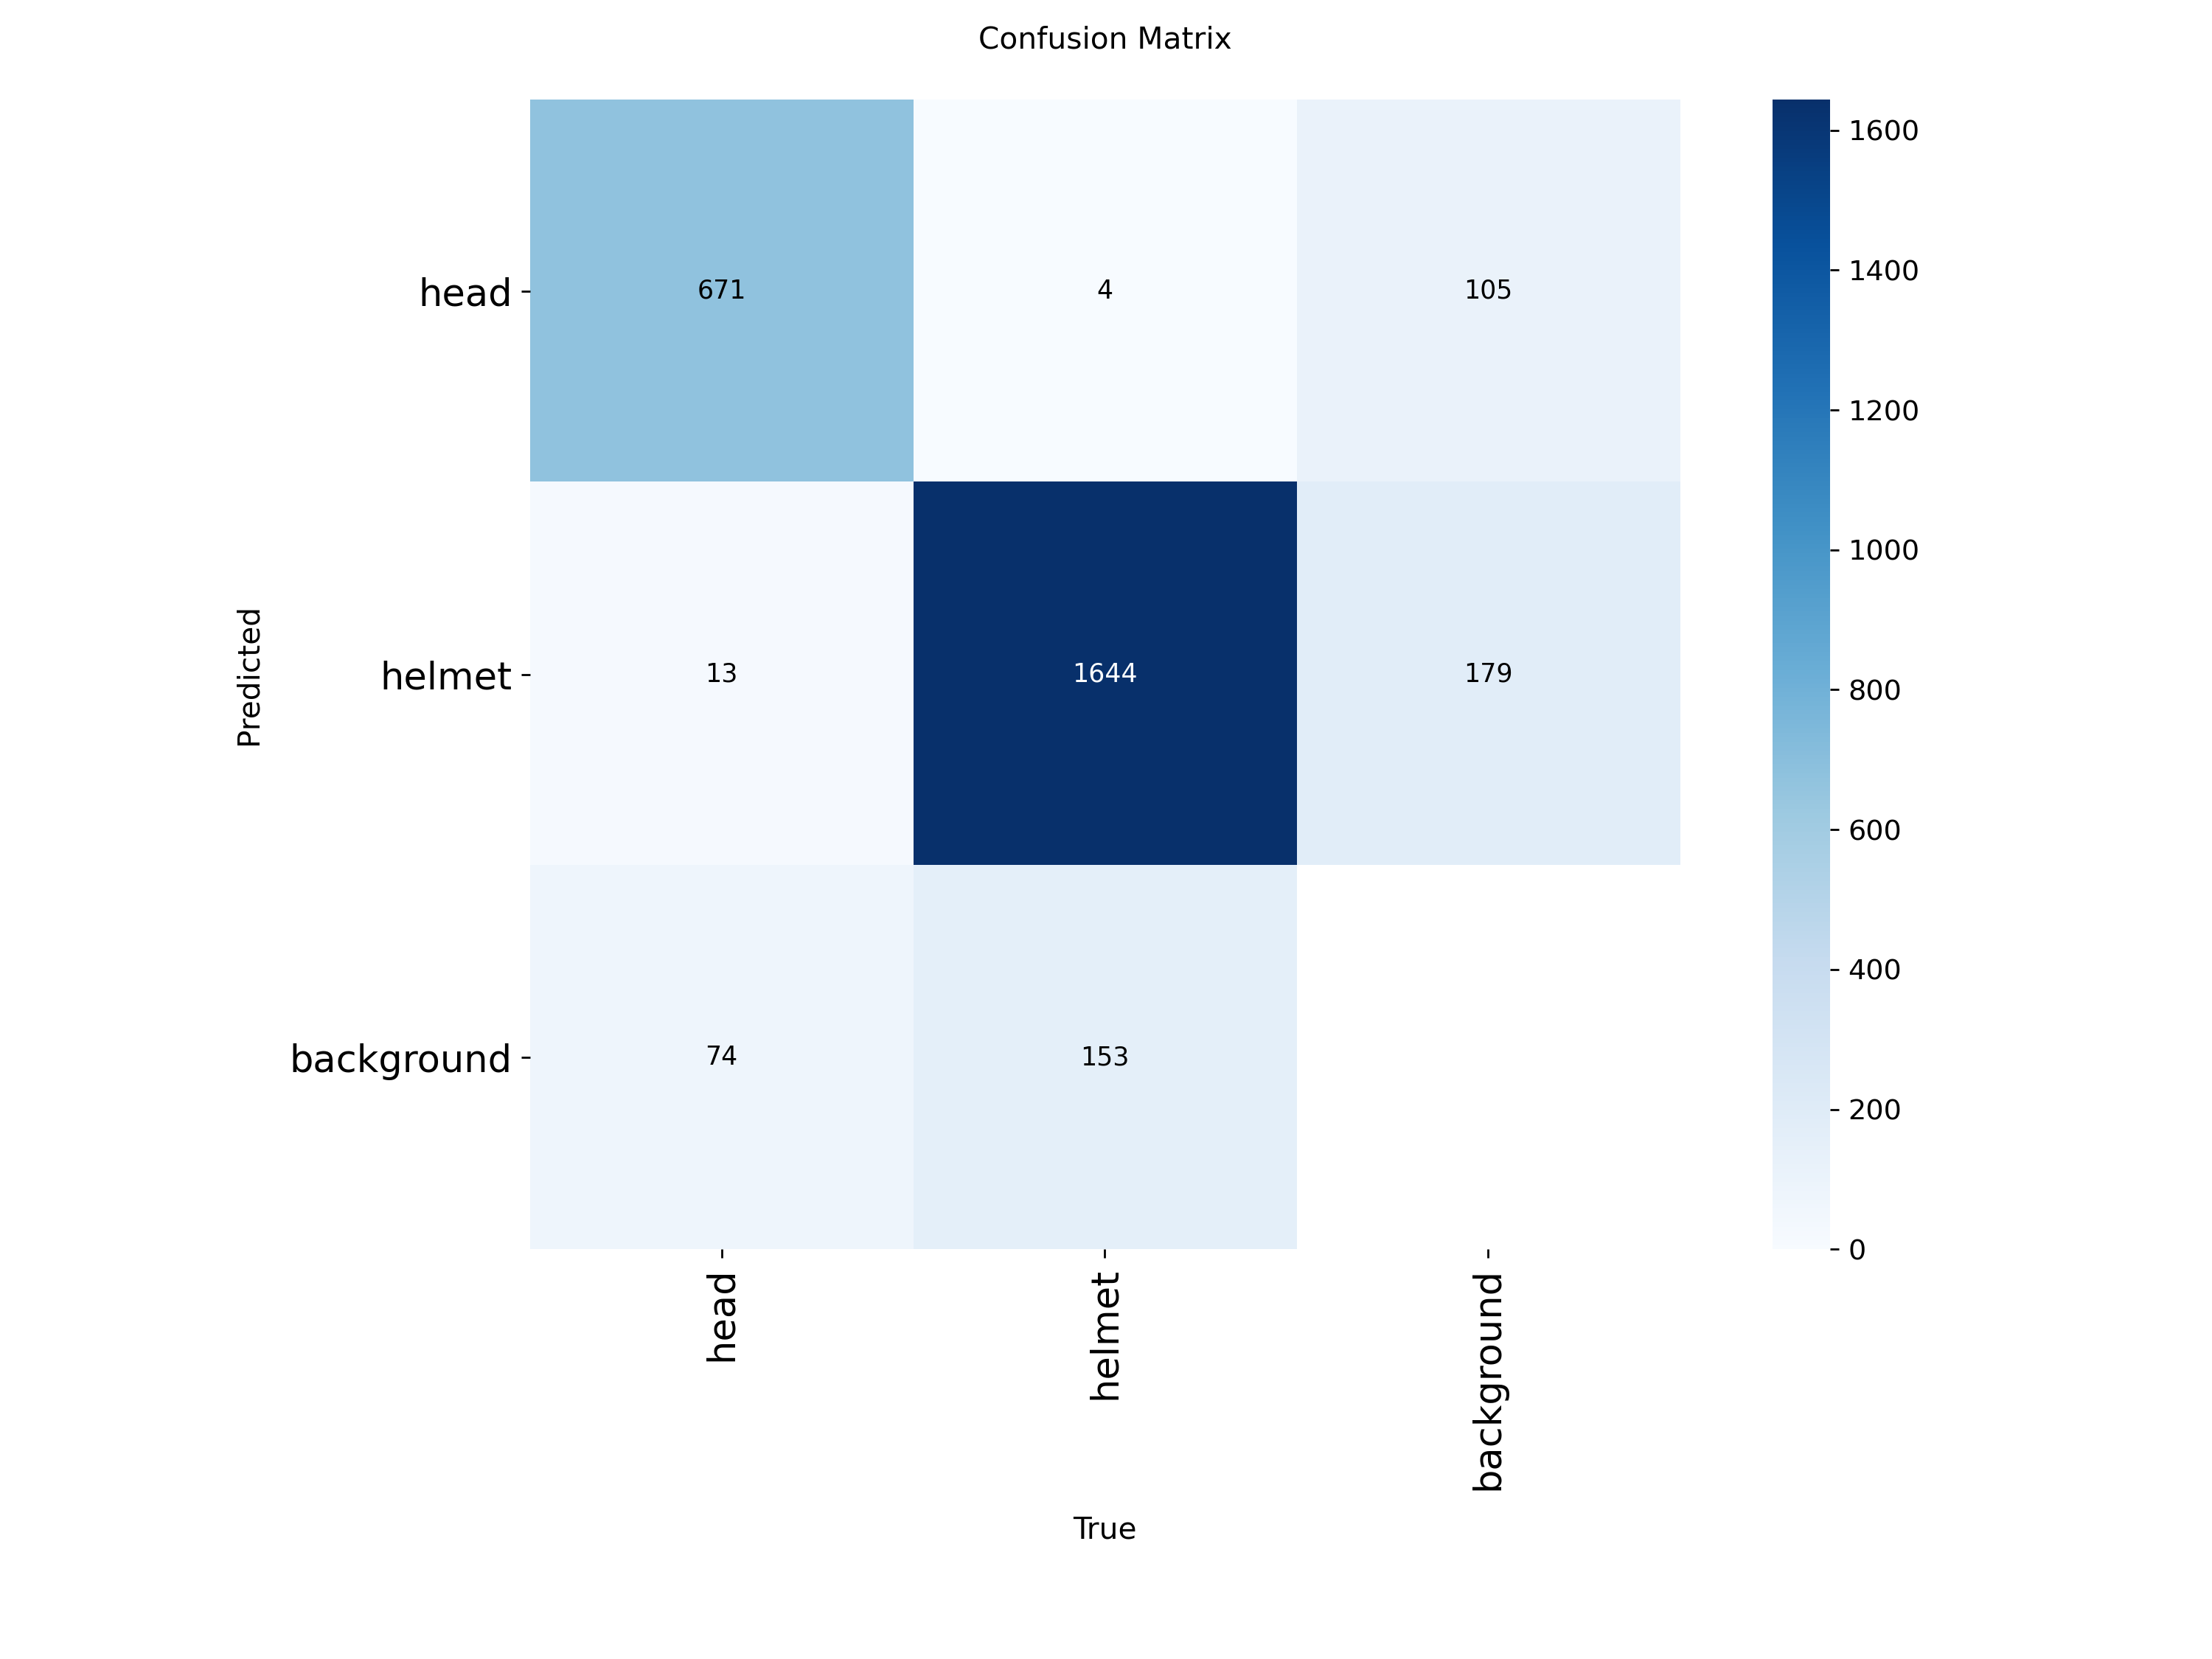

In [41]:
display(Image('/content/evaluations/test_eval_v1/confusion_matrix.png'))

Confusion matrix menunjukkan bahwa model mampu membedakan objek head dan helmet dengan baik. Kelas helmet memiliki hasil deteksi terbaik dengan 1644 prediksi benar, sedangkan head memiliki 671 prediksi benar. Kesalahan klasifikasi antar kedua kelas relatif rendah, sehingga model dapat dikatakan cukup akurat dan konsisten dalam mendeteksi kedua objek tersebut.

## Test Precision-Recall Curve

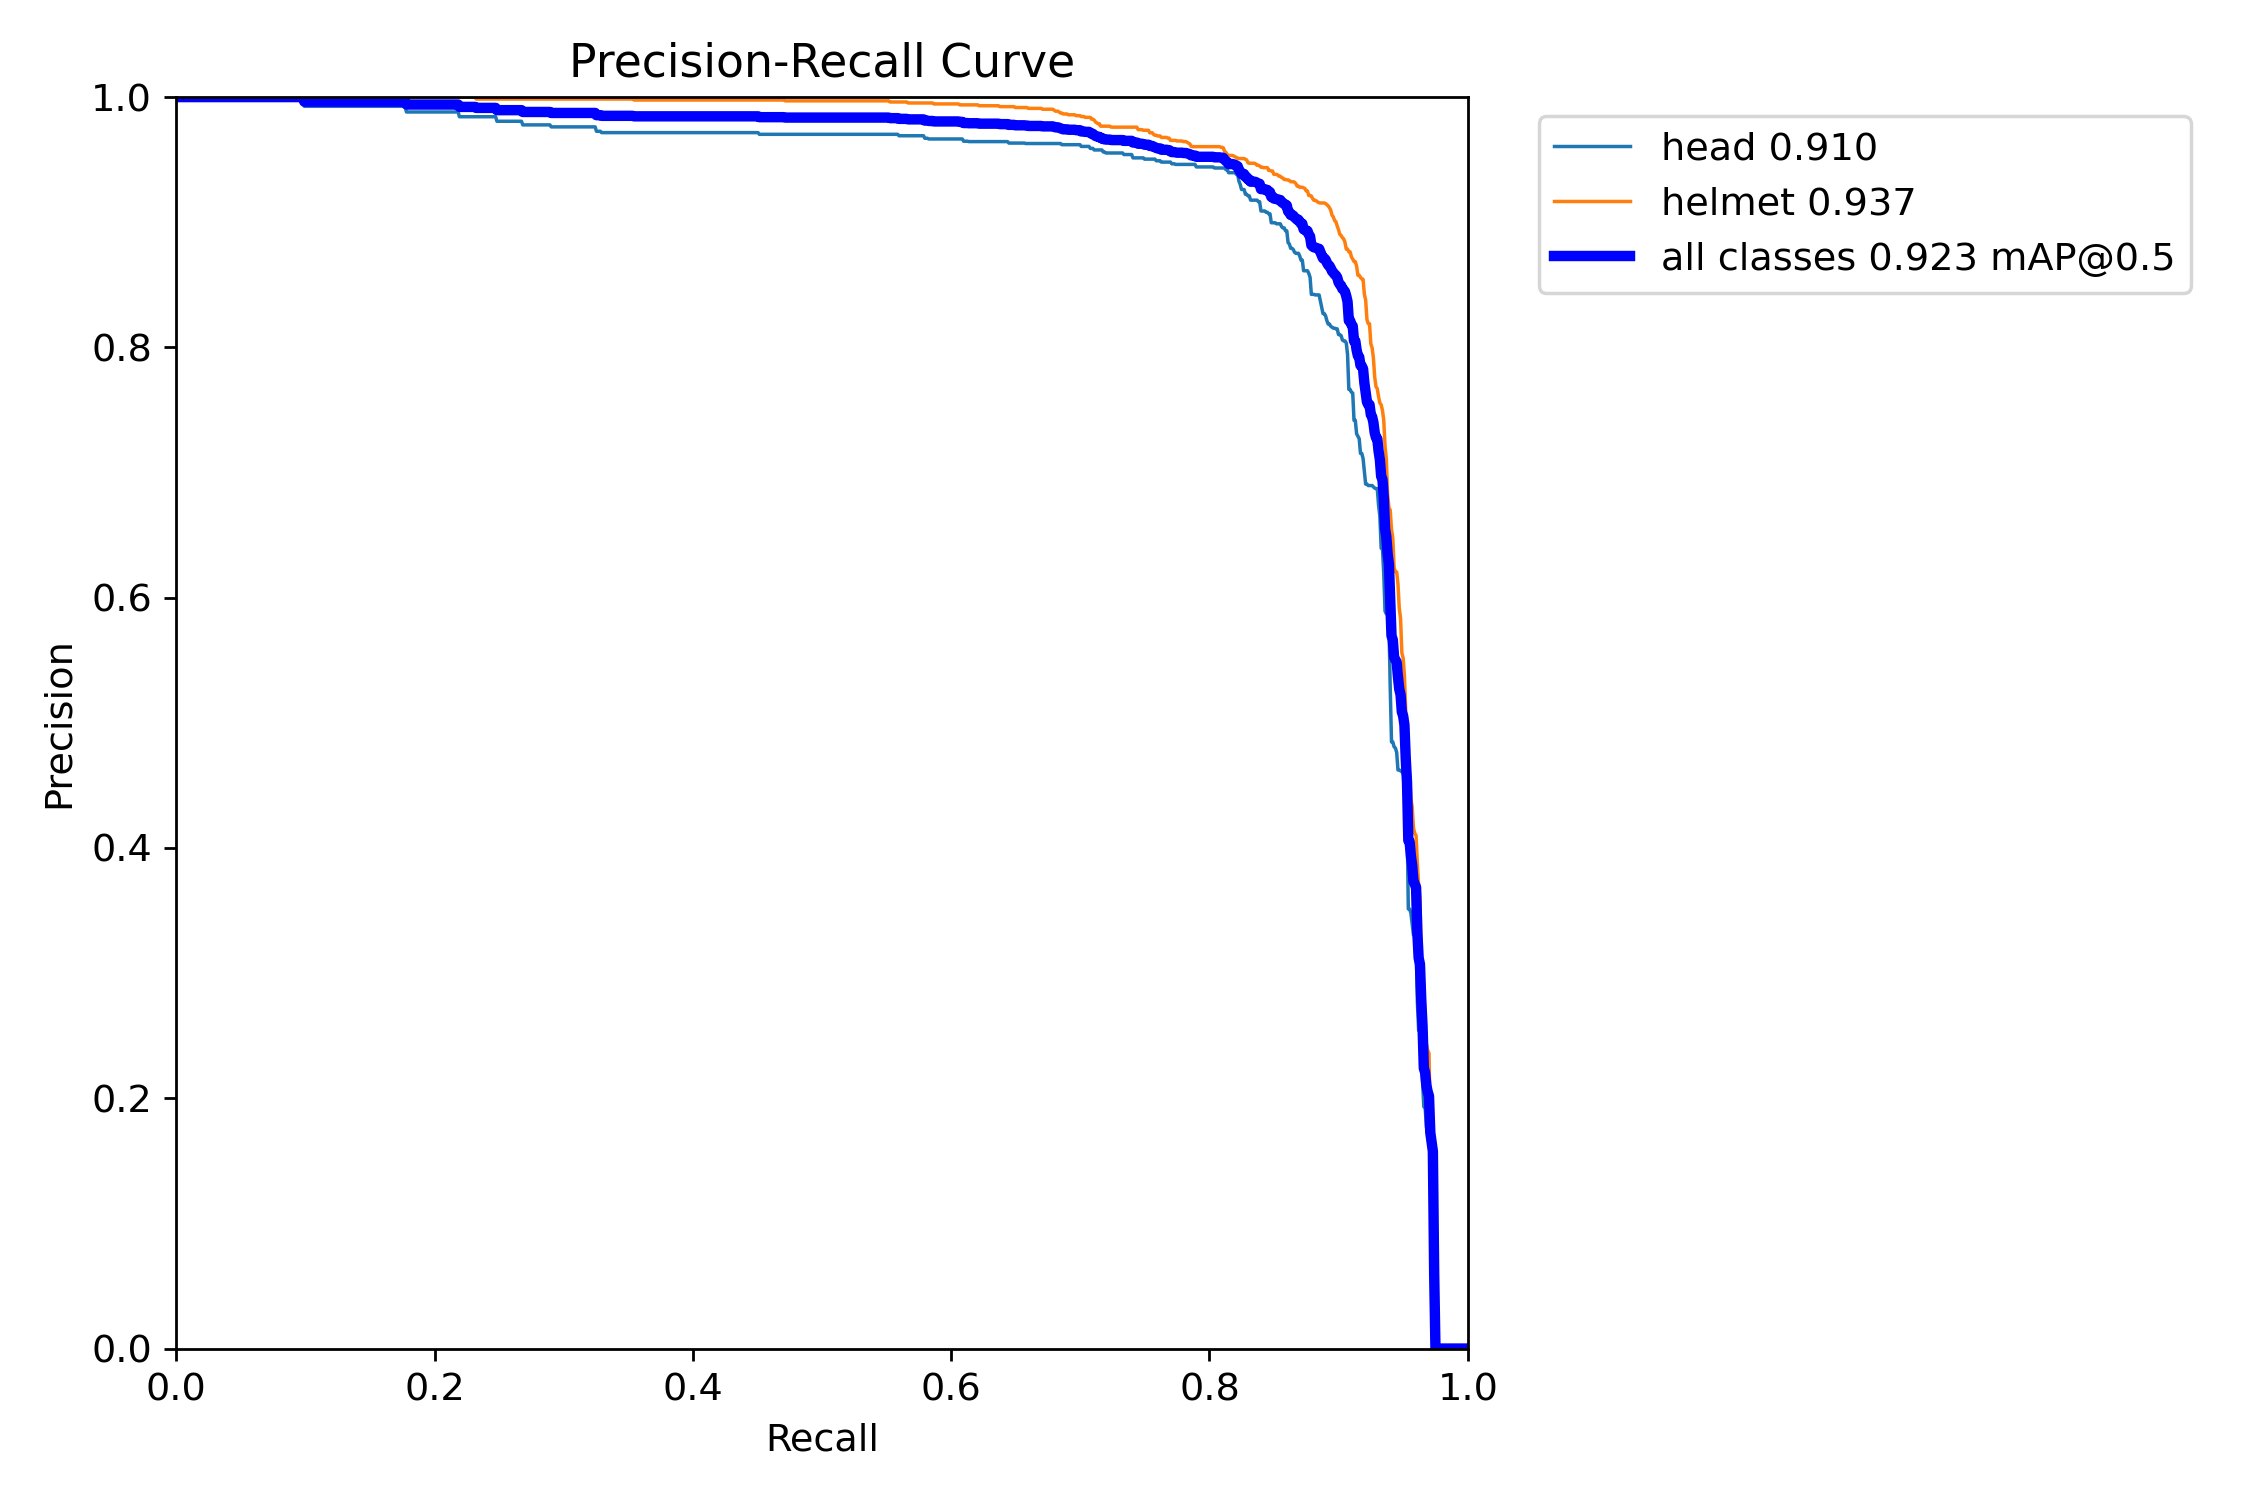

In [42]:
display(Image('/content/evaluations/test_eval_v1/BoxPR_curve.png'))

Dari grafik Precision-Recall Curve terlihat bahwa kelas head dan helmet memiliki performa yang sangat baik karena kurvanya berada dekat bagian atas grafik. Hal ini menunjukkan bahwa model mampu mempertahankan nilai precision yang tinggi sekaligus mendeteksi sebagian besar objek yang ada. Kelas helmet memiliki performa terbaik dengan nilai AP sebesar 0,937, sedangkan kelas head memperoleh AP sebesar 0,910.

Secara keseluruhan, model memperoleh mAP@0.5 sebesar 0,923, yang menunjukkan kemampuan deteksi yang sangat baik pada kedua kelas. Hasil ini menunjukkan bahwa model mampu mengenali objek head dan helmet dengan tingkat akurasi yang tinggi, dengan performa deteksi helmet yang sedikit lebih baik dibandingkan head.

## Test F1 Curve

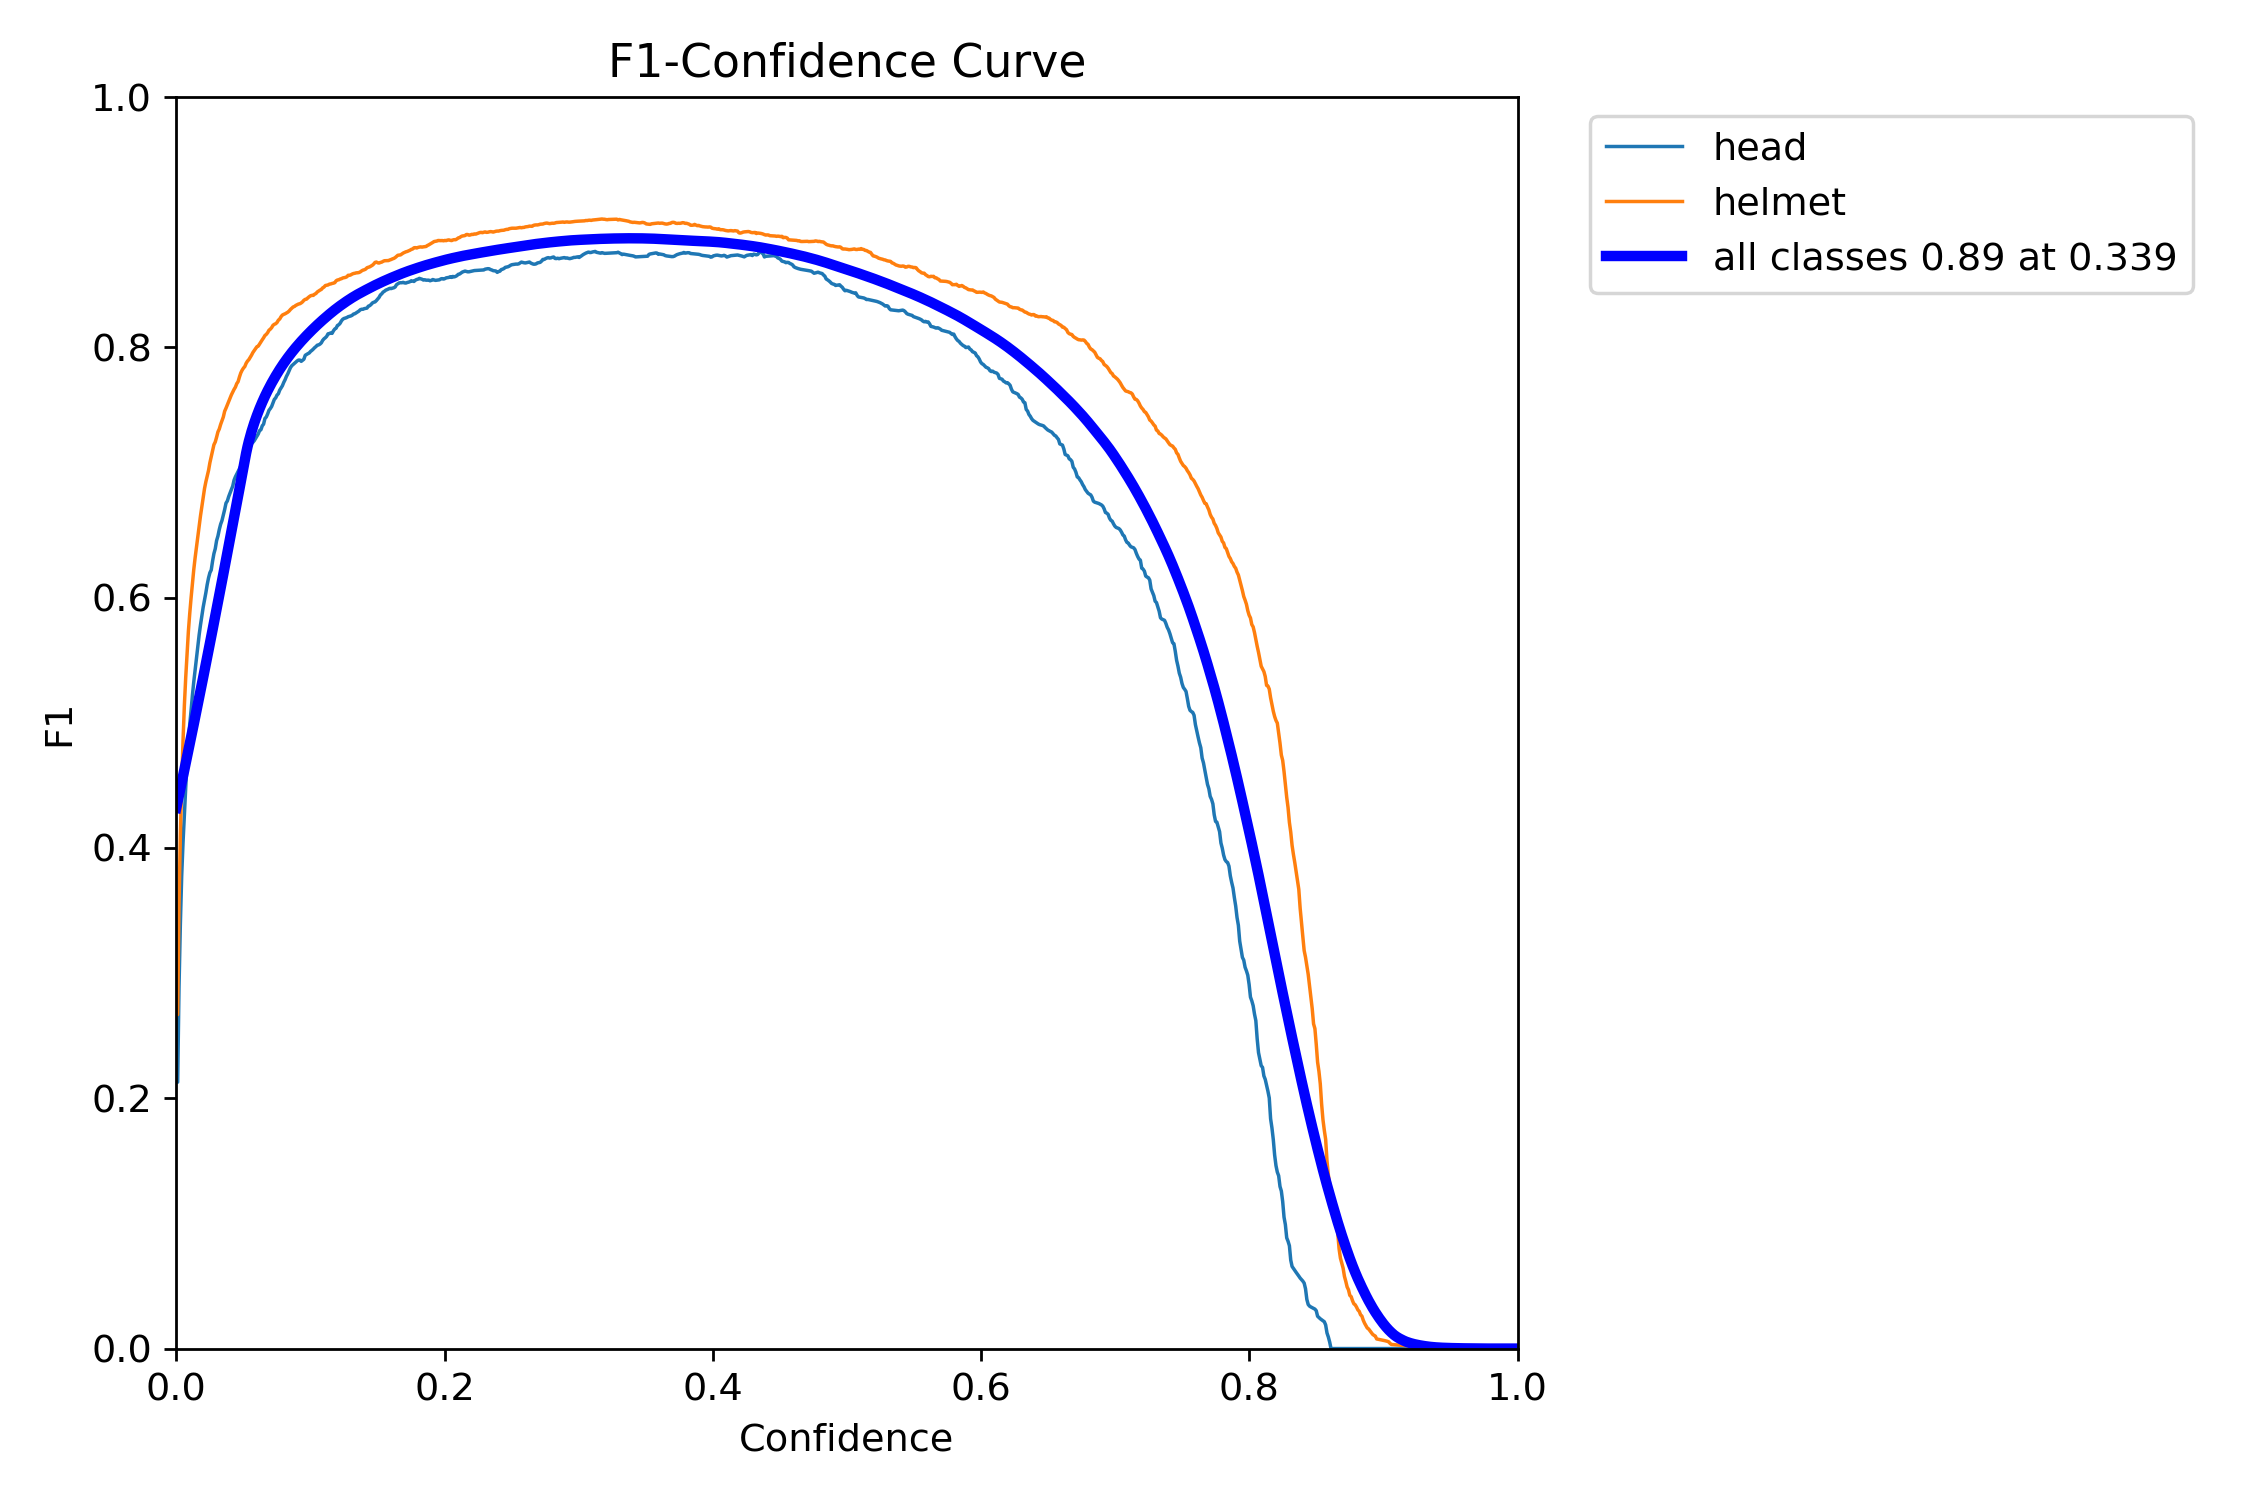

In [43]:
display(Image('/content/evaluations/test_eval_v1/BoxF1_curve.png'))

Grafik F1-Confidence menunjukkan bahwa kelas helmet memiliki performa sedikit lebih baik dibandingkan head. Nilai F1 terbaik model mencapai 0,89 pada confidence threshold 0,339, yang menunjukkan bahwa threshold tersebut merupakan titik optimal untuk mendapatkan keseimbangan terbaik antara precision dan recall.

## Test Recall Curve

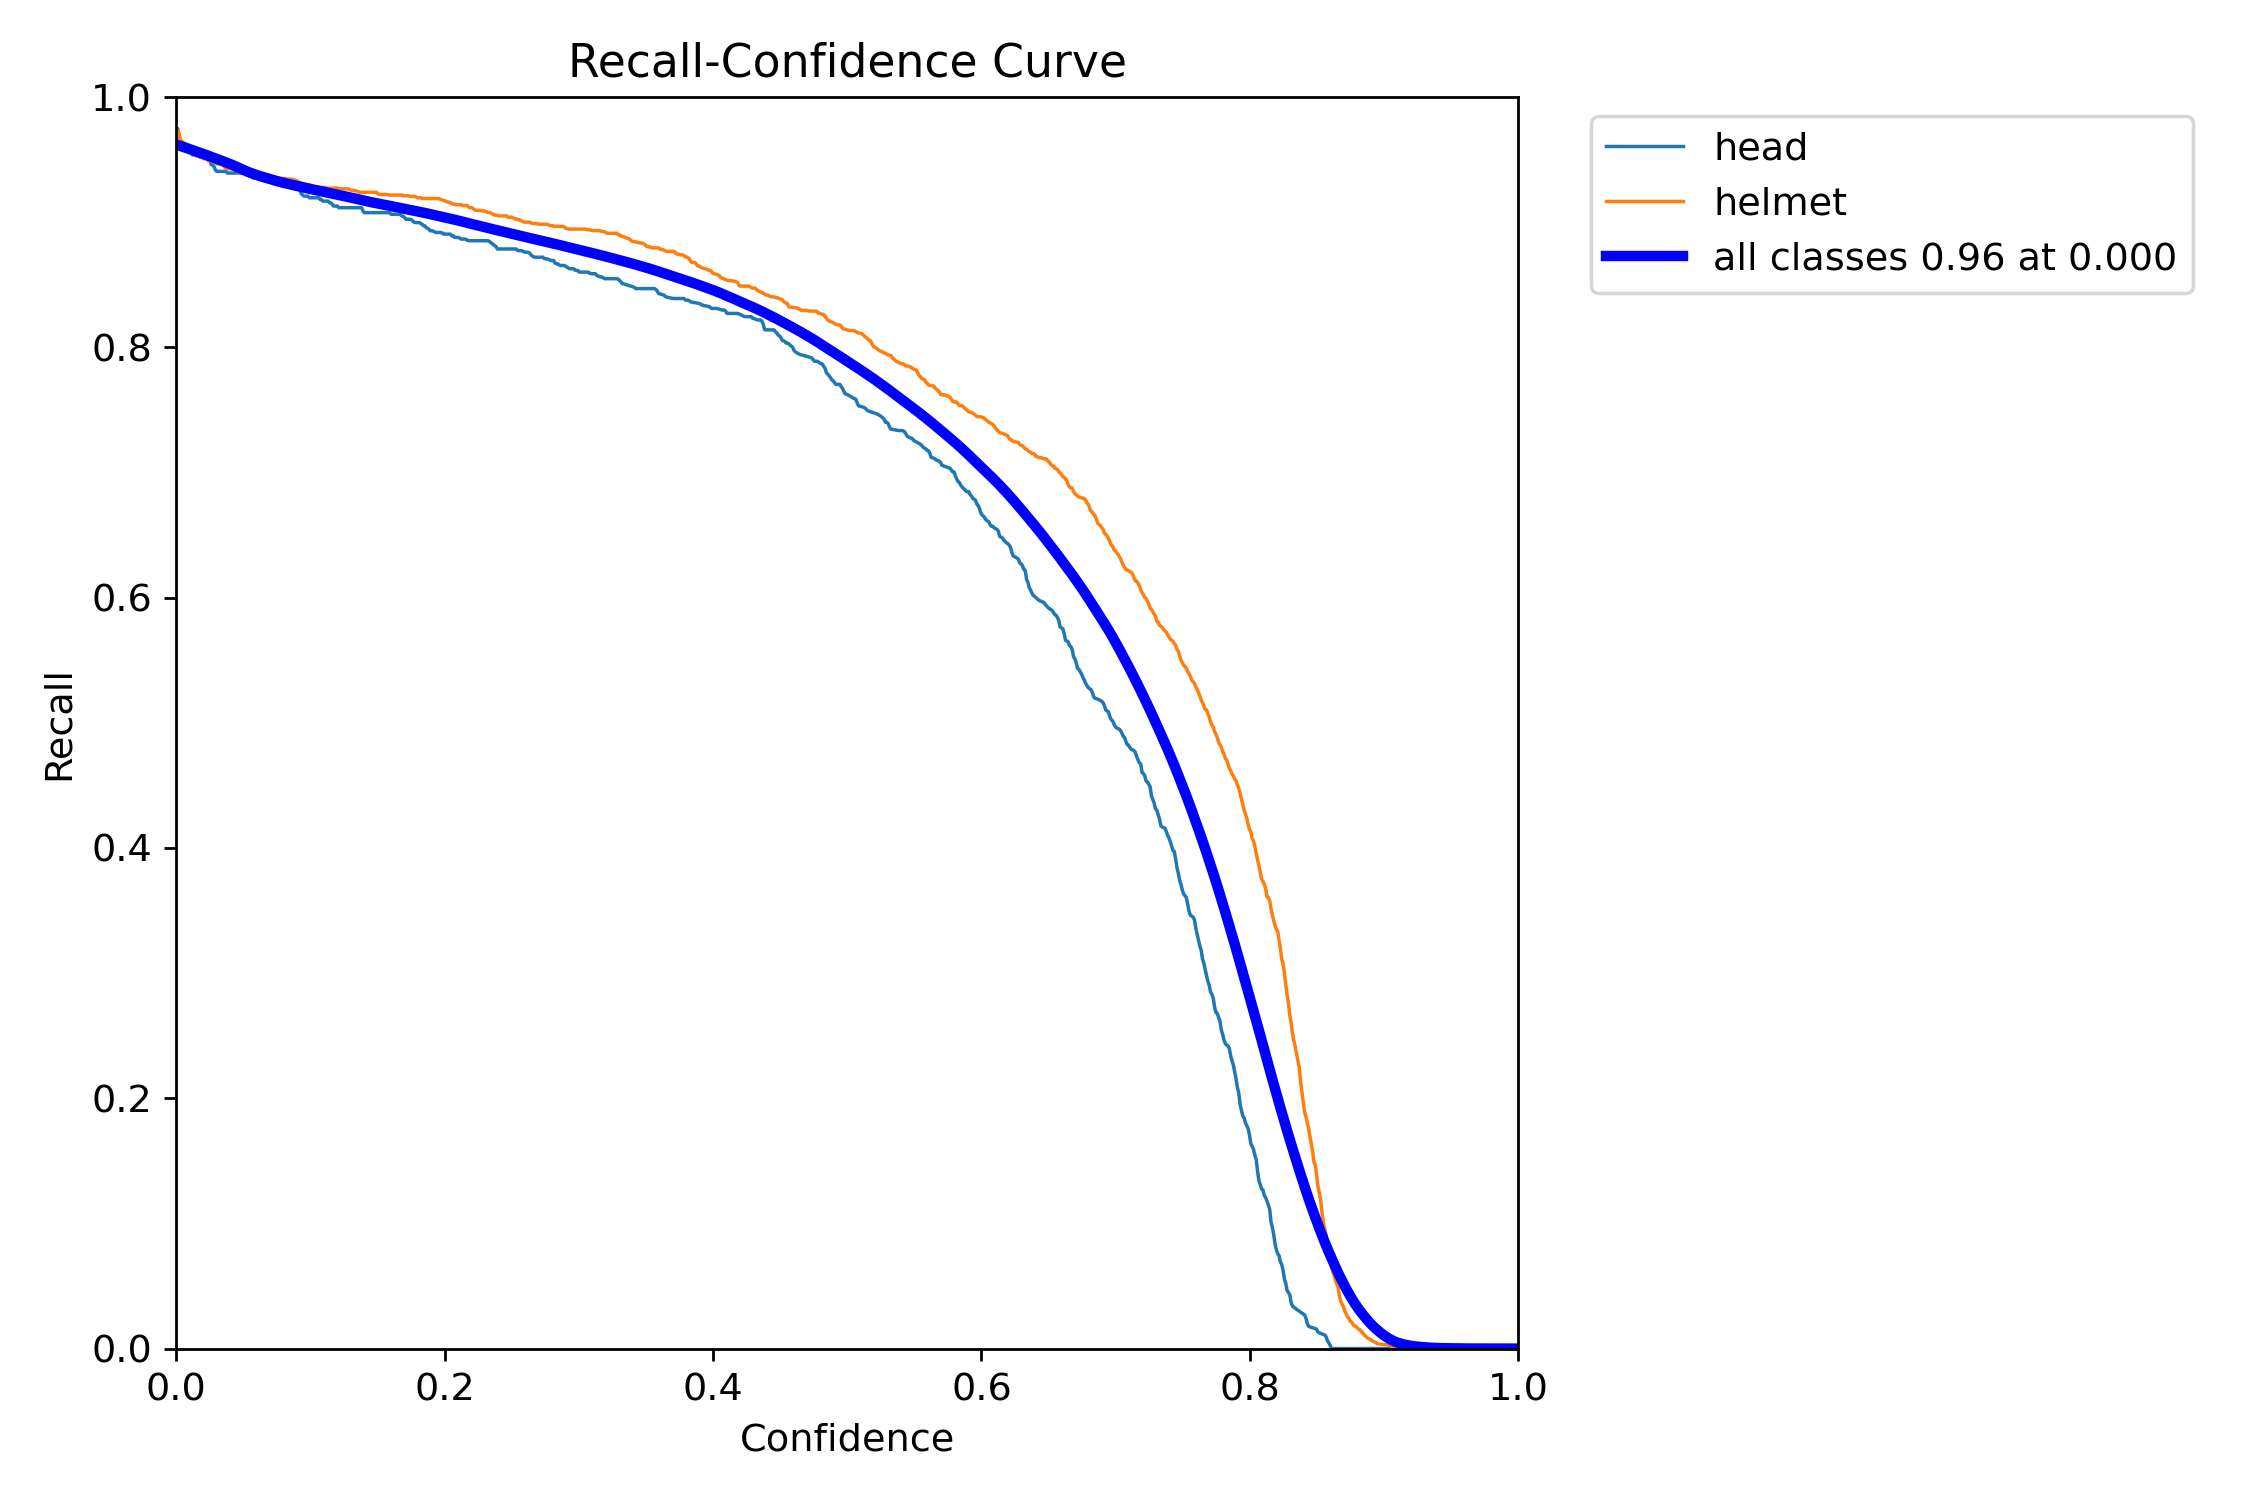

In [45]:
display(Image('/content/evaluations/test_eval_v1/BoxR_curve.png'))

Grafik Recall-Confidence menunjukkan bahwa nilai recall tertinggi diperoleh pada confidence threshold yang rendah, yaitu sekitar 0,96 untuk seluruh kelas. Seiring meningkatnya confidence threshold, nilai recall pada kedua kelas mengalami penurunan karena model menjadi lebih selektif dalam menerima prediksi.

Kelas helmet memiliki nilai recall yang sedikit lebih tinggi dibandingkan head pada hampir seluruh rentang confidence, yang menunjukkan bahwa model lebih konsisten dalam mendeteksi objek helmet. Selain itu, pola kurva yang menurun secara bertahap menunjukkan bahwa model mampu mempertahankan kemampuan deteksi yang baik hingga confidence menengah sebelum mengalami penurunan yang lebih tajam pada threshold yang tinggi.

## Sample Test Detection Results

Gunanya untuk melihat visualisasi hasil

In [46]:
results = model.predict(
    source='/content/Hard-Hat-Detection-1/test/images',
    save=True,
    conf=0.25
)


image 1/500 /content/Hard-Hat-Detection-1/test/images/hard_hat_workers1006_png.rf.256a979b0b85f9d8b2a68bd16af7e51b.jpg: 640x640 16 heads, 2 helmets, 11.1ms
image 2/500 /content/Hard-Hat-Detection-1/test/images/hard_hat_workers1018_png.rf.c50cb2c577064fbba7d47fb649da56ae.jpg: 640x640 3 helmets, 9.4ms
image 3/500 /content/Hard-Hat-Detection-1/test/images/hard_hat_workers1019_png.rf.9222efe332c6efb697531806a0c11125.jpg: 640x640 2 helmets, 9.2ms
image 4/500 /content/Hard-Hat-Detection-1/test/images/hard_hat_workers1020_png.rf.baa8a9818b49f4c547ed8ce1f30511cd.jpg: 640x640 8 helmets, 9.0ms
image 5/500 /content/Hard-Hat-Detection-1/test/images/hard_hat_workers1022_png.rf.9160c68da3e2854d01493902e1669fa0.jpg: 640x640 4 helmets, 9.0ms
image 6/500 /content/Hard-Hat-Detection-1/test/images/hard_hat_workers1023_png.rf.1628f4d867cfadb3564d456526e1ad7f.jpg: 640x640 8 helmets, 8.3ms
image 7/500 /content/Hard-Hat-Detection-1/test/images/hard_hat_workers1025_png.rf.65552c36a3a31e7638d84a10abf97d9f.jpg

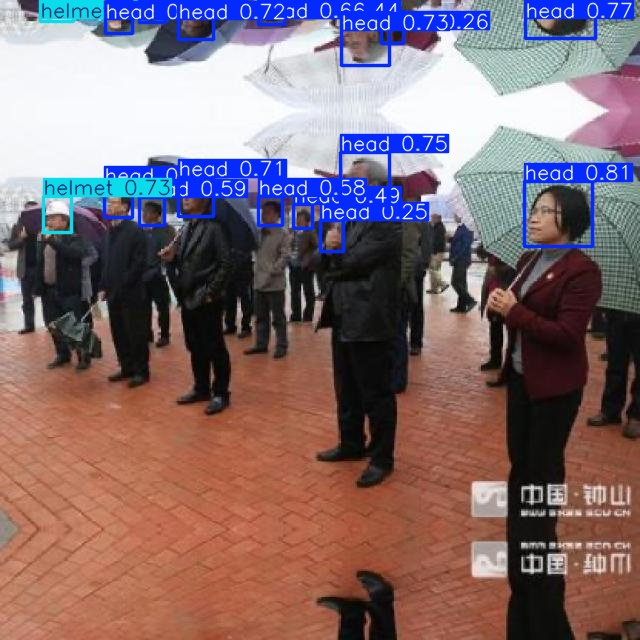

In [47]:
saved_image_path = os.path.join(results[0].save_dir, os.path.basename(results[0].path))
display(Image(saved_image_path))

Pada hasil prediksi terlihat bahwa model mampu mendeteksi objek head dan helmet dengan cukup baik, yang ditunjukkan oleh beberapa nilai confidence yang relatif tinggi, seperti 0,70 hingga 0,81. Model juga berhasil mengenali banyak objek dalam kondisi kerumunan dan berbagai posisi objek. Namun, masih terdapat beberapa prediksi dengan confidence yang lebih rendah serta beberapa bounding box yang kurang tepat, terutama pada objek yang berukuran kecil, saling berdekatan, atau sebagian tertutup oleh objek lain. Meskipun demikian, secara keseluruhan model menunjukkan kemampuan yang baik dalam mendeteksi objek head dan helmet pada kondisi yang cukup kompleks.

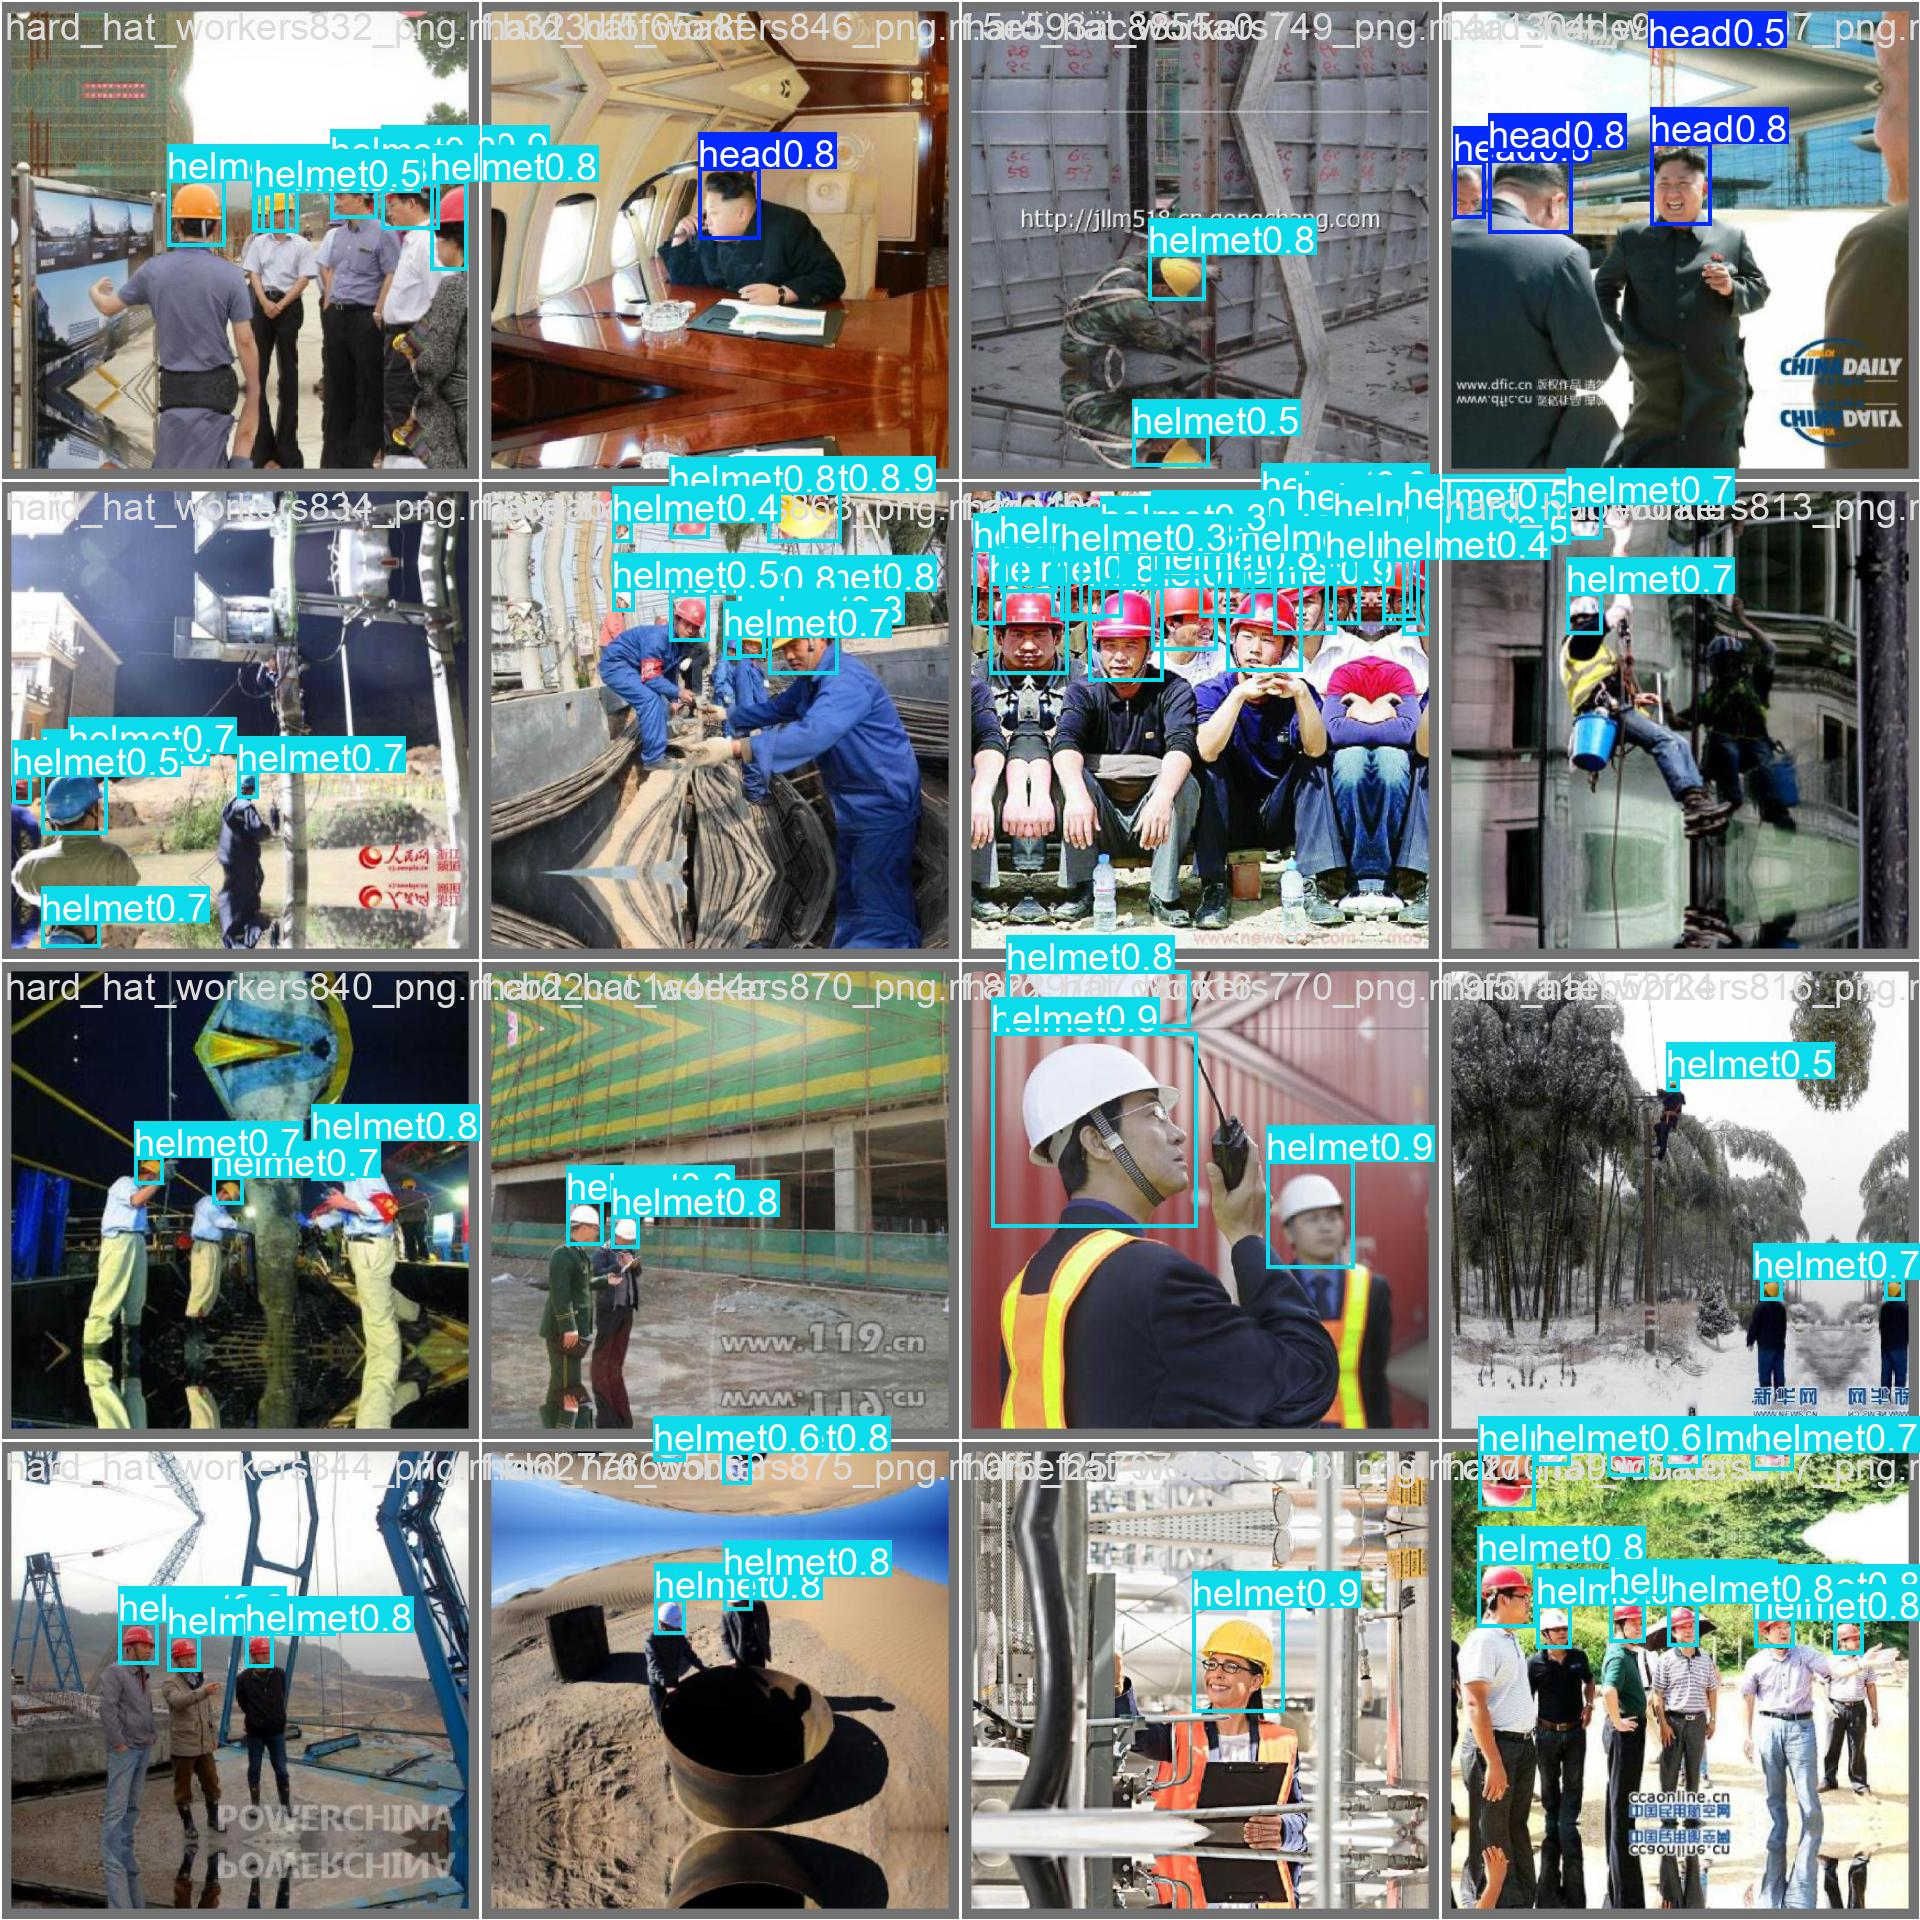

In [48]:
Image('/content/evaluations/test_eval_v1/val_batch0_pred.jpg')

Hasil validasi menunjukkan bahwa model sudah mampu mendeteksi objek head dan helmet dengan baik pada berbagai kondisi gambar. Sebagian besar prediksi memiliki confidence yang tinggi, yaitu sekitar 0,7 hingga 0,9. Meskipun masih terdapat beberapa bounding box yang bertumpuk pada area yang padat, secara keseluruhan model mampu melakukan deteksi secara akurat dan konsisten

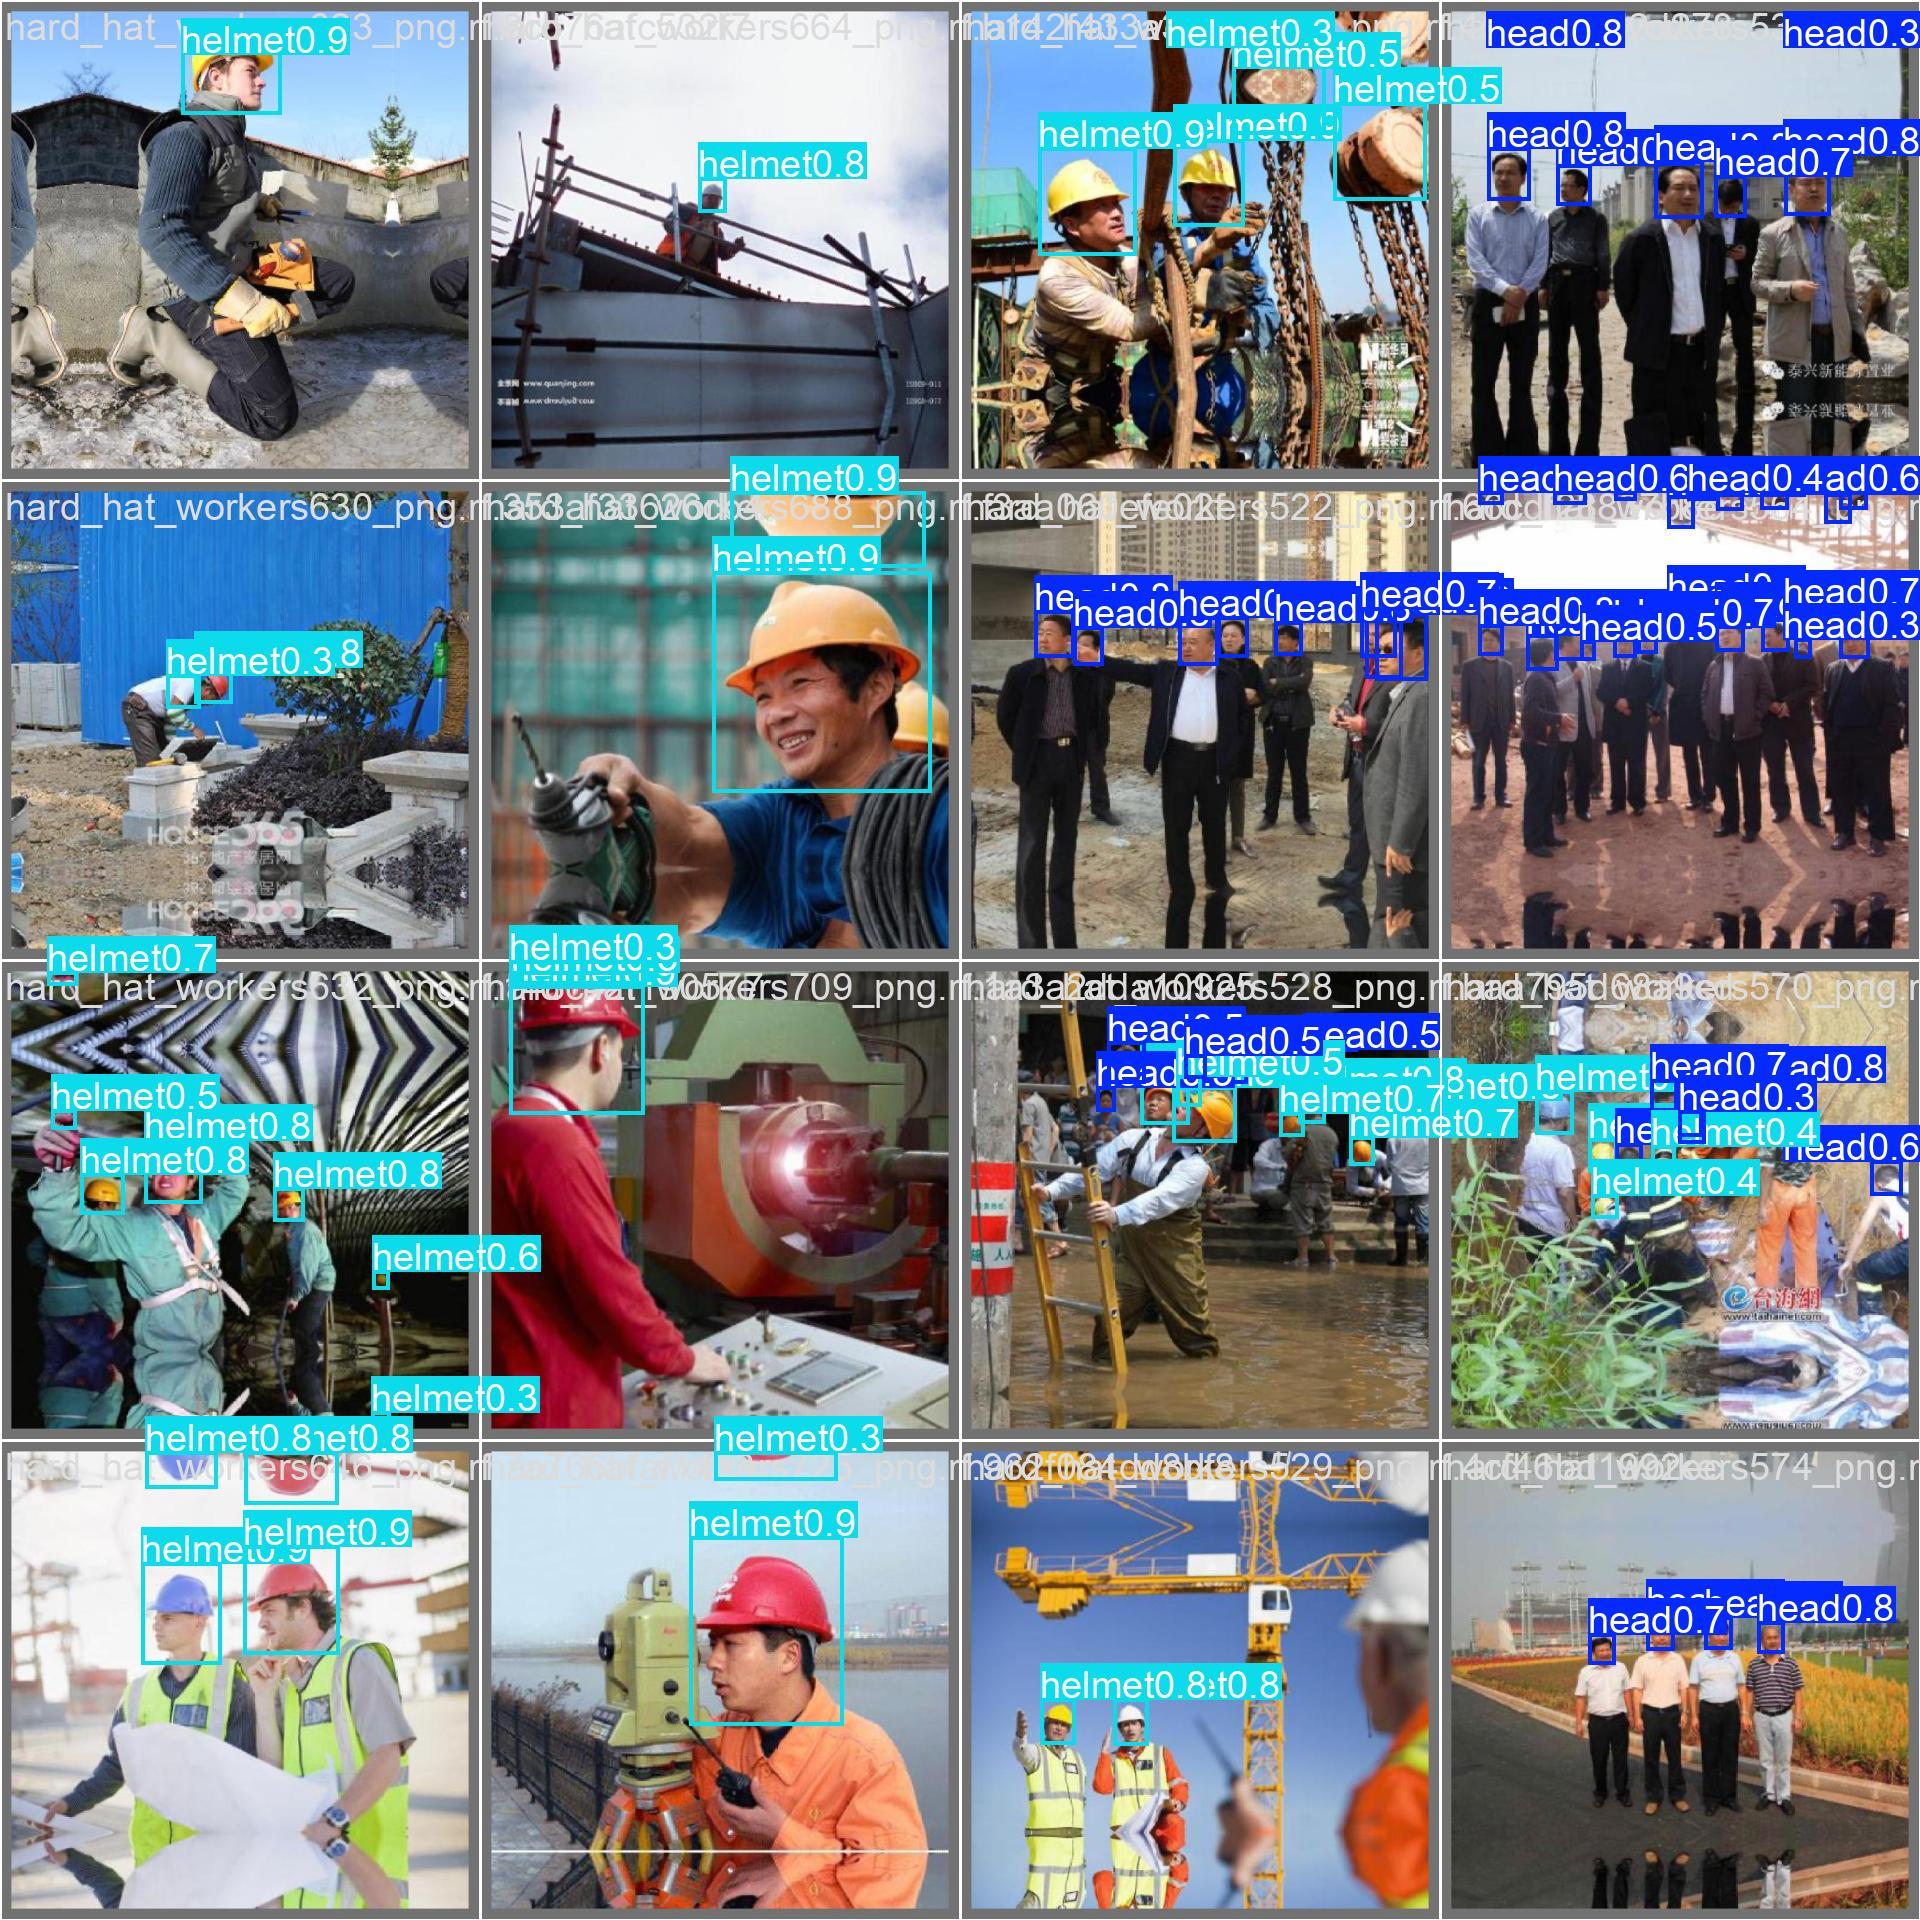

In [49]:
Image('/content/evaluations/test_eval_v1/val_batch1_pred.jpg')

Hasil validasi menunjukkan bahwa model mampu mendeteksi objek head dan helmet dengan cukup konsisten pada berbagai kondisi gambar. Sebagian besar prediksi memiliki confidence yang tinggi, terutama pada kelas helmet. Meskipun masih terdapat beberapa bounding box yang bertumpuk pada area yang padat, secara keseluruhan model mampu melakukan deteksi dengan baik dan cukup akurat.

Secara keseluruhan, berdasarkan hasil evaluasi dan visualisasi prediksi, model YOLO11n mampu mendeteksi objek head dan helmet dengan baik pada berbagai kondisi gambar, baik pada objek yang berukuran besar maupun kecil, serta pada lingkungan yang padat atau berisi banyak objek. Sebagian besar prediksi memiliki nilai confidence yang tinggi dan bounding box yang cukup sesuai dengan posisi objek sebenarnya.

Hasil pada Precision-Recall Curve, F1-Confidence Curve, Confusion Matrix, serta visualisasi batch prediction menunjukkan bahwa performa deteksi kedua kelas sudah cukup stabil dan konsisten. Kelas helmet memiliki performa yang sedikit lebih baik dibandingkan head, yang terlihat dari nilai AP, precision, recall, dan mAP yang lebih tinggi.

Meskipun demikian, masih terdapat beberapa kesalahan deteksi, seperti bounding box yang bertumpuk, objek yang terlewat, atau posisi bounding box yang kurang presisi pada gambar yang ramai, objek berukuran kecil, atau objek yang saling berdekatan. Namun secara keseluruhan, model telah menunjukkan kemampuan deteksi yang baik dan memiliki potensi untuk diterapkan pada sistem pemantauan penggunaan helm keselamatan secara otomatis.

Terlihat bahwa model cukup konsisten dalam mendeteksi objek helmet, dengan banyak prediksi memiliki nilai confidence yang tinggi, yaitu sekitar 0,8–0,9. Hal ini menunjukkan bahwa model mampu mengenali objek helmet dengan baik pada berbagai kondisi gambar, baik ketika objek berada dekat kamera, berukuran kecil, maupun berada dalam kerumunan.

Pada kelas head, model juga mampu melakukan deteksi dengan cukup baik, meskipun beberapa prediksi memiliki nilai confidence yang lebih rendah dibandingkan kelas helmet. Hal ini menunjukkan bahwa model masih sedikit lebih sulit mengenali objek head, terutama pada kondisi objek yang saling berdekatan, sebagian tertutup, atau memiliki ukuran yang lebih kecil.

Secara keseluruhan, hasil visualisasi menunjukkan bahwa model lebih konsisten dalam mendeteksi helmet dibandingkan head, namun kedua kelas tetap dapat dikenali dengan baik dan menghasilkan performa deteksi yang cukup akurat.

# Existing Challenges

* Beberapa objek yang berukuran kecil, saling berdekatan, atau berada pada area yang ramai masih sulit dideteksi secara sempurna, sehingga terkadang muncul bounding box yang bertumpuk atau kurang presisi.
* Distribusi data yang tidak seimbang, di mana jumlah objek helmet jauh lebih banyak dibandingkan head, dapat menyebabkan performa deteksi helmet sedikit lebih baik daripada head.
* Masih terdapat beberapa prediksi dengan confidence yang relatif rendah, terutama pada objek yang sebagian tertutup (occlusion), berukuran kecil, atau berada pada kondisi pencahayaan yang kurang ideal.

# Future Opportunities

* Menambah jumlah dan variasi dataset, terutama untuk kelas head, agar model dapat belajar lebih seimbang dan meningkatkan kemampuan generalisasi.

* Menggunakan model YOLO versi yang lebih besar atau training lebih lama agar hasil deteksi lebih akurat.

* Melakukan data augmentation seperti brightness, atau blur agar model lebih tahan terhadap berbagai kondisi gambar.

* Model ini bisa dikembangkan untuk sistem safety monitoring real-time di area konstruksi atau industri untuk memastikan pekerja menggunakan helmet dengan benar.


In [50]:
best_model_path = f"{results[0].save_dir}/weights/best.pt"
print(best_model_path)

/content/runs/detect/predict/weights/best.pt


In [51]:
import os

for root, dirs, files in os.walk('/content/runs/detect'):
    if 'best.pt' in files:
        print(os.path.join(root, 'best.pt'))

/content/runs/detect/train/weights/best.pt


In [52]:
from google.colab import files

files.download('/content/runs/detect/train/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>